# 아세트아미노펜(Acetaminophen) 복합제 3종 부작용 비교 분석

FDA FAERS 이상사례 데이터셋(`아세트아미노펜_51개브랜드_전체행_최종.csv`, 총 1,248건)에서 아래 3개 성분 조합에 해당하는 행만 추출해 비교합니다.

- **Acetaminophen + Diphenhydramine** — 예: Tylenol PM (야간용/수면유도 진통제)
- **Acetaminophen + Phenylephrine** — 예: Tylenol Cold (비충혈제거 감기약)
- **Acetaminophen + Dextromethorphan** — 예: Children's Tylenol Cold (진해거담 감기약)

세 조합은 모두 아세트아미노펜을 공유하지만, 함께 배합된 부성분의 약리 기전이 서로 달라 이상사례 패턴에도 차이가 나타납니다. 이 노트북은 (1) 데이터 필터링 → (2) 시각화 → (3) 각 그룹의 도메인 지식 및 출처 순으로 구성되어 있습니다.


In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib as mpl

# macOS 한글 폰트 (다른 OS라면 'Malgun Gothic'(Windows) / 'NanumGothic'(Linux)로 교체)
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_colwidth', 120)


In [2]:
df = pd.read_csv('아세트아미노펜_51개브랜드_전체행_최종.csv', encoding='utf-8-sig')
print(f'전체 행 수: {len(df)}, 컬럼 수: {df.shape[1]}')

# 컬럼이 39개이고 그중 일부(참조_* 등)는 긴 한글 문장이라, 미리보기는 핵심 컬럼만 선별해서 확인
preview_cols = ['report_id', 'receive_date', 'brand_name', '전체_활성성분',
                'serious', 'is_fatal', 'is_hospitalized', 'age_group', 'patient_sex']
df[preview_cols].head(3)


전체 행 수: 1248, 컬럼 수: 39


,report_id,receive_date,brand_name,전체_활성성분,serious,is_fatal,is_hospitalized,age_group,patient_sex
0,10019350,2015-02-24,TYLENOL COLD PLUS HEAD CONGESTION SEVERE; TYLENOL REGULAR STRENGTH; TYLENOL EXTRA STRENGTH,TYLENOL COLD PLUS HEAD CONGESTION SEVERE: Acetaminophen + Phenylephrine; TYLENOL REGULAR STRENGTH: Acetaminophen; TY...,Yes,True,True,Unknown,Male
1,10019352,2015-02-24,AMAZON BASIC CARE ACETAMINOPHEN; PAIN RELIEF; MAXIMUM STRENGTH NON-ASPIRIN 100; MAXIMUM STRENGTH NON-ASPIRIN 250; IN...,AMAZON BASIC CARE ACETAMINOPHEN: Acetaminophen; PAIN RELIEF: Acetaminophen(제품별 상이 가능); MAXIMUM STRENGTH NON-ASPIRIN ...,Yes,False,True,Unknown,Unknown
2,10083990,2015-02-24,TYLENOL EXTRA STRENGTH; TYLENOL EXTRA STRENGTH CAPLET,TYLENOL EXTRA STRENGTH: Acetaminophen; TYLENOL EXTRA STRENGTH CAPLET: Acetaminophen,Yes,True,True,Adult(19-40),Female


## 1. 그룹 필터링

`전체_활성성분` 컬럼은 각 보고 건(report)에 연루된 브랜드별 성분 조합을 `"브랜드명: 성분1 + 성분2"` 형태로 나열합니다. 이 문자열에 대상 조합이 포함된 행을 각 그룹으로 추출합니다.

> **주의**: 세 그룹은 완전히 배타적이지 않습니다(한 보고 건에 여러 브랜드가 동시에 연루된 경우 중복 포함될 수 있음). 실제로 1건이 Diphenhydramine·Phenylephrine 두 그룹에 동시 해당됩니다.


In [3]:
combos = {
    'Diphenhydramine': 'Acetaminophen + Diphenhydramine',
    'Phenylephrine': 'Acetaminophen + Phenylephrine',
    'Dextromethorphan': 'Acetaminophen + Dextromethorphan',
}
colors = {
    'Diphenhydramine': '#2a78d6',
    'Phenylephrine': '#eb6834',
    'Dextromethorphan': '#1baf7a',
}

groups = {}
for name, pattern in combos.items():
    mask = df['전체_활성성분'].str.contains(pattern, regex=False, na=False)
    groups[name] = df[mask].copy()

for name, sub in groups.items():
    print(f'{name:<18} n={len(sub):>4}  (전체의 {len(sub)/len(df)*100:.1f}%)')


Diphenhydramine    n=  14  (전체의 1.1%)
Phenylephrine      n= 171  (전체의 13.7%)
Dextromethorphan   n=  36  (전체의 2.9%)


## 2. 중증도 지표 비교

보고 건 중 심각(serious) 판정·사망·입원·생명위협·후유장애로 이어진 비율(%)을 비교합니다.


In [4]:
summary_rows = []
for name, sub in groups.items():
    summary_rows.append({
        '조합': name,
        'n': len(sub),
        '심각(%)': round((sub['serious'] == 'Yes').mean() * 100, 1),
        '사망(%)': round(sub['is_fatal'].mean() * 100, 1),
        '입원(%)': round(sub['is_hospitalized'].mean() * 100, 1),
        '생명위협(%)': round(sub['is_life_threat'].mean() * 100, 1),
        '후유장애(%)': round(sub['is_disabling'].mean() * 100, 1),
        '회복(%)': round(sub['patient_recovered'].mean() * 100, 1),
    })
summary_df = pd.DataFrame(summary_rows).set_index('조합')
summary_df


,n,심각(%),사망(%),입원(%),생명위협(%),후유장애(%),회복(%)
조합,,,,,,,
Diphenhydramine,14,78.6,14.3,78.6,0.0,0.0,42.9
Phenylephrine,171,80.1,15.8,46.8,6.4,2.9,27.5
Dextromethorphan,36,33.3,5.6,5.6,2.8,0.0,11.1


/tmp/ipykernel_1733/4051376001.py:16: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4051376001.py:16: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4051376001.py:16: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4051376001.py:16: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4051376001.py:16: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4051376001.py:16: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4051376001.py:16: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight

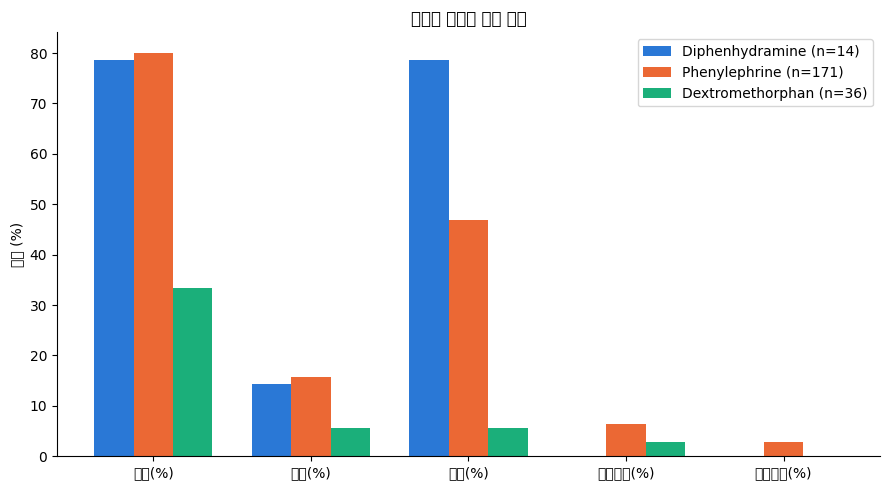

In [5]:
metrics = ['심각(%)', '사망(%)', '입원(%)', '생명위협(%)', '후유장애(%)']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(groups.keys()):
    vals = summary_df.loc[name, metrics].values
    ax.bar(x + (i - 1) * width, vals, width, label=f'{name} (n={len(groups[name])})', color=colors[name])

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('비율 (%)')
ax.set_title('조합별 중증도 지표 비교')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**관찰**: Diphenhydramine·Phenylephrine 조합은 심각 판정 비율이 약 80%로 비슷하게 높은 반면, Dextromethorphan 조합은 33.3%로 뚜렷하게 낮습니다. Phenylephrine 조합은 사망률(15.8%)과 생명위협 비율(6.4%)이 세 그룹 중 가장 높고, Diphenhydramine 조합은 입원 비율(78.6%)이 가장 두드러집니다.

## 3. 연령대 · 성별 분포

제품의 용도(야간 진통제 / 감기약 / 소아용 기침약)에 따라 실제 사용 연령층이 다르게 나타나는지 확인합니다.


/tmp/ipykernel_1733/3519679075.py:17: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3519679075.py:17: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3519679075.py:17: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3519679075.py:17: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3519679075.py:17: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3519679075.py:17: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3519679075.py:17: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_lay

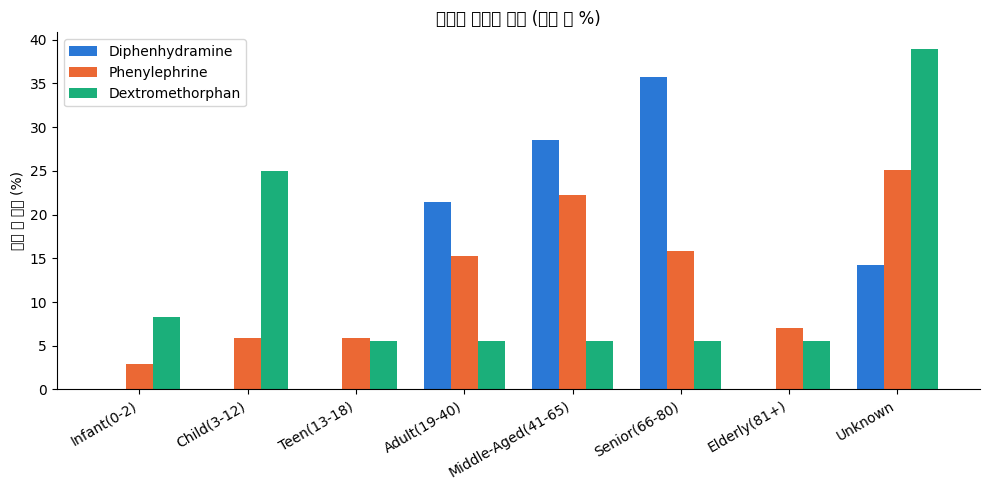

In [6]:
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']

fig, ax = plt.subplots(figsize=(10, 5))
xw = np.arange(len(age_order))
for i, (name, sub) in enumerate(groups.items()):
    counts = sub['age_group'].value_counts()
    pct = [counts.get(a, 0) / len(sub) * 100 for a in age_order]
    ax.bar(xw + (i - 1) * width, pct, width, label=name, color=colors[name])

ax.set_xticks(xw)
ax.set_xticklabels(age_order, rotation=30, ha='right')
ax.set_ylabel('그룹 내 비율 (%)')
ax.set_title('조합별 연령대 분포 (그룹 내 %)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1733/2214628963.py:17: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2214628963.py:17: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2214628963.py:17: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2214628963.py:17: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2214628963.py:17: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2214628963.py:17: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2214628963.py:17: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  plt.tight

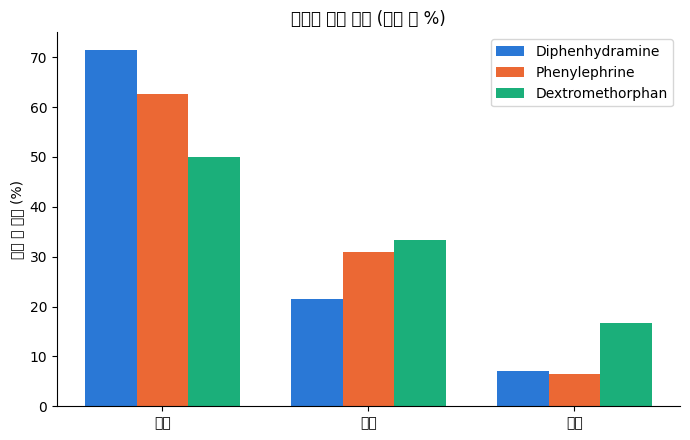

In [7]:
sex_order = ['Female', 'Male', 'Unknown']
sex_labels_ko = {'Female': '여성', 'Male': '남성', 'Unknown': '미상'}

fig, ax = plt.subplots(figsize=(7, 4.5))
xs = np.arange(len(sex_order))
for i, (name, sub) in enumerate(groups.items()):
    counts = sub['patient_sex'].value_counts()
    pct = [counts.get(s, 0) / len(sub) * 100 for s in sex_order]
    ax.bar(xs + (i - 1) * width, pct, width, label=name, color=colors[name])

ax.set_xticks(xs)
ax.set_xticklabels([sex_labels_ko[s] for s in sex_order])
ax.set_ylabel('그룹 내 비율 (%)')
ax.set_title('조합별 성별 분포 (그룹 내 %)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**관찰**: Dextromethorphan 조합은 영아(0-2세)·소아(3-12세) 비중이 다른 두 그룹보다 뚜렷하게 높아 소아용 기침감기약의 사용 패턴을 반영합니다. Diphenhydramine·Phenylephrine 조합은 중년~고령층(41세 이상) 비중이 높고, 세 그룹 모두 여성 보고 비율이 남성보다 높습니다(FAERS 자발보고에서 흔히 관찰되는 경향).

## 4. 조합별 상위 이상반응(Reaction)

각 그룹에서 가장 많이 보고된 이상반응 Top 6입니다. 부성분(항히스타민 / 혈관수축제 / 진해제)의 약리 기전이 그대로 드러납니다.


/tmp/ipykernel_1733/765401296.py:19: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/765401296.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


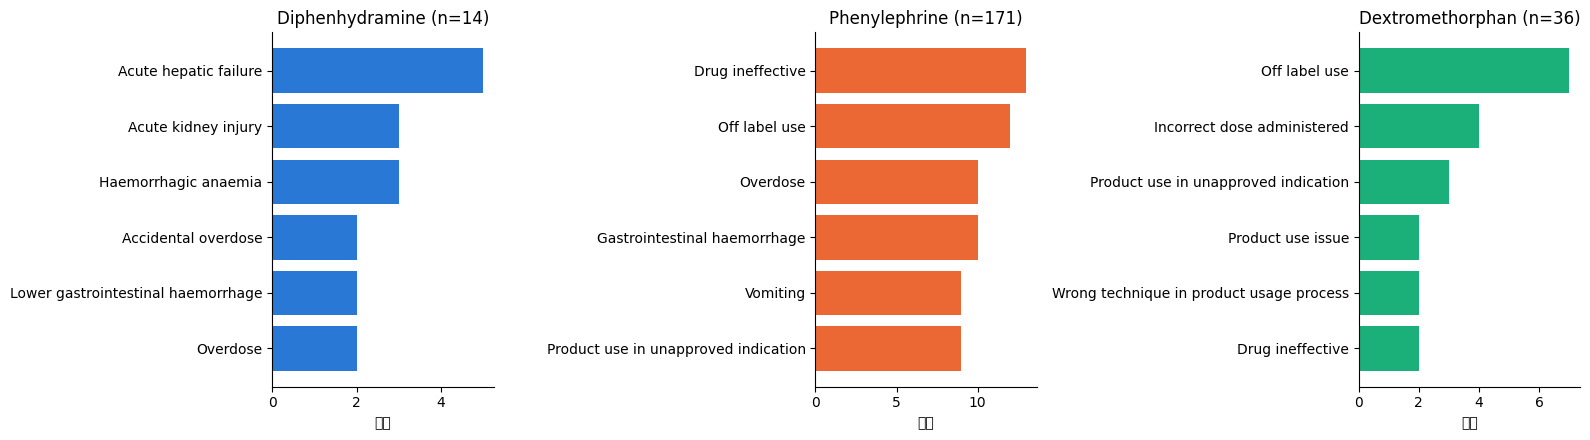

In [8]:
def top_reactions(sub, n=6):
    c = Counter()
    for r in sub['reactions'].dropna():
        for item in re.split(r';\s*', str(r)):
            item = item.strip()
            if item:
                c[item] += 1
    return c.most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, sub) in zip(axes, groups.items()):
    rx = top_reactions(sub)
    labels = [r[0] for r in rx][::-1]
    vals = [r[1] for r in rx][::-1]
    ax.barh(labels, vals, color=colors[name])
    ax.set_title(f'{name} (n={len(sub)})')
    ax.set_xlabel('건수')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**관찰**:
- **Diphenhydramine**: 급성 간부전(Acute hepatic failure)이 최다 — 아세트아미노펜 간독성과 직결
- **Phenylephrine**: "Drug ineffective"(약효 없음)가 최다 — 아래 도메인 지식 참고
- **Dextromethorphan**: "Off label use", "Incorrect dose administered" 등 투약오류 계열이 상위권 — 소아 오남용과 연관


---

## 5. 그룹별 단독 심층 분석

지금까지는 세 그룹을 나란히 놓고 비교했습니다. 이번에는 조합을 하나씩 따로 뜯어보며 그룹 내부의 패턴을 확인합니다. 각 조합마다 (1) 중증도 breakdown, (2) 연령 분포, (3) 성별 분포, (4) 병용약물 수 분포, (5) 적응증 Top5, (6) 이상반응 Top8을 하나의 대시보드로 묶어서 봅니다.


In [9]:
def plot_group_dashboard(name, sub, color):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'{name} 조합 단독 분석 (n={len(sub)})', fontsize=14, y=1.02)

    # (0,0) 중증도 breakdown
    ax = axes[0, 0]
    sev_metrics = ['심각', '사망', '입원', '생명위협', '후유장애']
    sev_vals = [
        (sub['serious'] == 'Yes').mean() * 100,
        sub['is_fatal'].mean() * 100,
        sub['is_hospitalized'].mean() * 100,
        sub['is_life_threat'].mean() * 100,
        sub['is_disabling'].mean() * 100,
    ]
    bars = ax.bar(sev_metrics, sev_vals, color=color)
    ax.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=9)
    ax.set_ylim(0, max(sev_vals + [10]) * 1.25)
    ax.set_title('중증도 breakdown')
    ax.spines[['top', 'right']].set_visible(False)

    # (0,1) 연령 분포
    ax = axes[0, 1]
    age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
                 'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']
    counts = sub['age_group'].value_counts()
    pct = [counts.get(a, 0) / len(sub) * 100 for a in age_order]
    ax.bar(age_order, pct, color=color)
    ax.set_xticks(range(len(age_order)))
    ax.set_xticklabels(age_order, rotation=40, ha='right', fontsize=8)
    ax.set_title('연령대 분포 (%)')
    ax.spines[['top', 'right']].set_visible(False)

    # (0,2) 성별 분포
    ax = axes[0, 2]
    sex_order = ['Female', 'Male', 'Unknown']
    sex_labels_ko = {'Female': '여성', 'Male': '남성', 'Unknown': '미상'}
    counts = sub['patient_sex'].value_counts()
    pct = [counts.get(s, 0) / len(sub) * 100 for s in sex_order]
    ax.bar([sex_labels_ko[s] for s in sex_order], pct, color=color)
    ax.set_title('성별 분포 (%)')
    ax.spines[['top', 'right']].set_visible(False)

    # (1,0) 병용약물 수 분포
    ax = axes[1, 0]
    drug_order = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)', 'Unknown']
    counts = sub['drug_count_category'].value_counts()
    pct = [counts.get(d, 0) / len(sub) * 100 for d in drug_order]
    ax.bar(drug_order, pct, color=color)
    ax.set_xticks(range(len(drug_order)))
    ax.set_xticklabels(drug_order, rotation=30, ha='right', fontsize=8)
    ax.set_title('병용약물 수 분포 (%)')
    ax.spines[['top', 'right']].set_visible(False)

    # (1,1) 적응증 Top5
    ax = axes[1, 1]
    ind = sub['drug_indication'].value_counts().head(5)[::-1]
    ax.barh(ind.index, ind.values, color=color)
    ax.set_title('적응증(indication) Top5')
    ax.set_xlabel('건수')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # (1,2) 이상반응 Top8
    ax = axes[1, 2]
    rx = top_reactions(sub, n=8)[::-1]
    labels = [r[0] for r in rx]
    vals = [r[1] for r in rx]
    ax.barh(labels, vals, color=color)
    ax.set_title('이상반응(reaction) Top8')
    ax.set_xlabel('건수')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()


### 5.1 Acetaminophen + Diphenhydramine (n=14)

/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

병용약물 수: {'Polypharmacy(6+)': 7, '2-3 Drugs': 5, '4-5 Drugs': 2}
적응증 Top5: {'Product Used For Unknown Indication': 5, 'Sleep Disorder': 3, 'Pain': 2, 'Insomnia': 1, 'Toothache': 1}
연도별 건수: {'2015': 2, '2016': 2, '2017': 3, '2019': 4, '2020': 1, '2021': 2}


/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

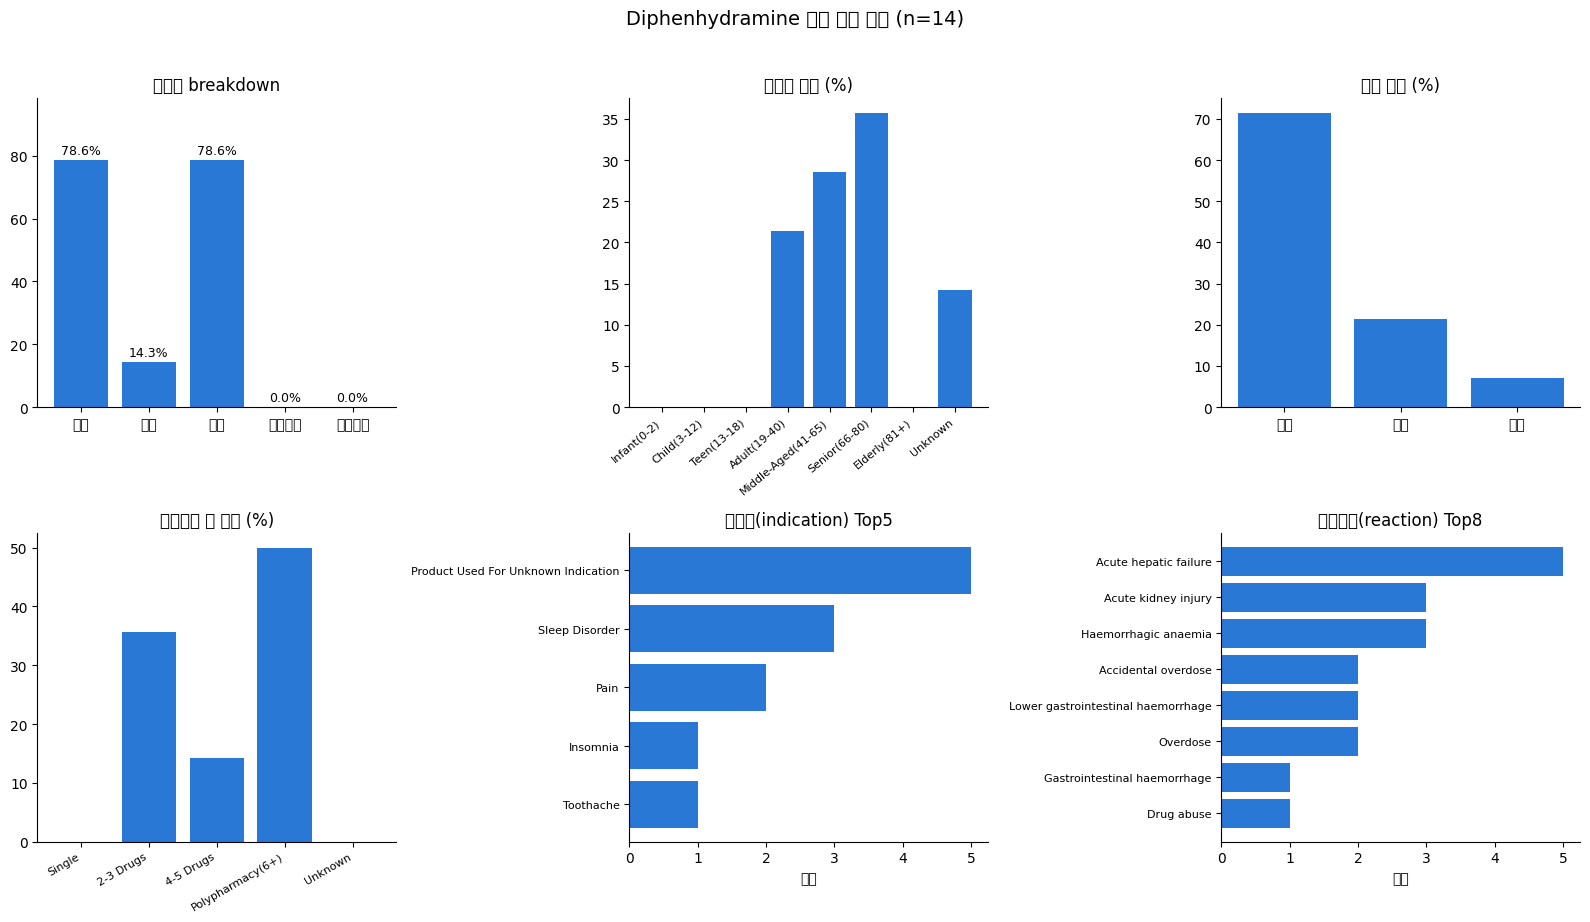

In [10]:
sub = groups['Diphenhydramine']
print('병용약물 수:', sub['drug_count_category'].value_counts().to_dict())
print('적응증 Top5:', sub['drug_indication'].value_counts().head(5).to_dict())
print('연도별 건수:', sub['quarter'].str[:4].value_counts().sort_index().to_dict())

plot_group_dashboard('Diphenhydramine', sub, colors['Diphenhydramine'])


**대시보드 6개 그래프별 인사이트**

① **중증도 breakdown** — 심각 78.6%·입원 78.6%로 거의 동률 최고 수준, 사망도 14.3%로 높은 편. 반면 생명위협 0%·후유장애 0%. 즉 즉각적인 쇼크성 위해라기보다 **간부전처럼 서서히 진행되는 장기손상형 중증** 패턴에 가깝습니다.

② **연령대 분포** — 19세 미만 0%, Senior(66-80) 35.7%가 최다이고 Middle-Aged(28.6%)까지 합치면 41세 이상이 64.3%. 성인 전용 야간 진통제라는 제품 라벨링과 정확히 일치합니다.

③ **성별 분포** — 여성 71.4%로 세 그룹 중 가장 여성 편중이 뚜렷합니다(다만 n=14라 소수 사례 하나가 비율을 크게 흔들 수 있음에 유의).

④ **병용약물 수 분포** — Single(단독복용) 0%, Polypharmacy(6+) 50%. **14건 전부가 다약제 병용 상태**로, 주간용/야간용 이중 복용과 만성질환 동반약물이 겹치는 구조적 위험을 보여줍니다.

⑤ **적응증 Top5** — Unknown(35.7%) > Sleep Disorder(21.4%) > Pain(14.3%) > Insomnia·Toothache(각 7.1%). 수면 관련이 명시된 것만 28.6%지만, Unknown 비중까지 고려하면 실제 야간 복용 목적 비중은 더 클 가능성이 있습니다.

⑥ **이상반응 Top8** — Acute hepatic failure가 최다(5건, 35.7%)로 세 그룹 중 가장 뚜렷한 간독성 집중을 보입니다. Acute kidney injury·Haemorrhagic anaemia가 뒤를 이어 **다장기 손상형 급성 중독**의 전형적 양상을 나타냅니다.

**왜 이런 패턴이 나타날까? (기전)**
- *병용약물 100%*: 이 조합은 대부분 "이미 복용 중인 진통제/수면제에 추가"하는 방식으로 쓰입니다. 디펜히드라민이 강한 **H1 수용체 길항(항히스타민) 작용으로 뇌혈관장벽을 통과해 진정 효과**를 내기 때문에, 낮에는 아세트아미노펜 단일제(Regular/Extra Strength)를 먹고 밤에는 PM 제형으로 바꿔 먹는 "주간-야간 이중 복용" 패턴이 흔합니다. 이 과정에서 두 제품 모두에 아세트아미노펜이 들어있다는 걸 인지하지 못해 **치료적 중복(therapeutic duplication)**이 발생하고, 여기에 만성질환약을 함께 복용하는 중장년·고령층 특성이 더해져 병용약물 수가 구조적으로 높게 나타납니다.
- *수면 적응증 쏠림*: 이는 우연이 아니라 **약물 설계 자체의 결과**입니다. 디펜히드라민의 1차 약리작용(중추 H1 차단 → 각성 신경전달 억제 → 졸림)을 역이용해 "PM=야간용" 콘셉트로 제품화한 것이므로, 적응증이 수면/불면에 몰리는 것은 정확히 의도된 약효가 보고서에 그대로 반영된 결과입니다.
- *19세 미만 0건*: 두 가지 요인이 겹칩니다. (1) 마케팅·라벨링상 "PM" 계열은 성인 대상으로만 표시·판매되고, (2) 약리학적으로도 항히스타민제는 **소아에서 진정 대신 역설적 흥분(paradoxical excitation)** 반응을 보이는 경우가 있어 소아 수면유도 목적으로는 애초에 권장되지 않습니다. 따라서 사용자 모집단 자체가 성인 이상으로 한정됩니다.
- *간독성 집중(⑥)*: ①의 지연형 중증 패턴과 직결됩니다 — 아세트아미노펜은 간에서 대사되는 과정(글루타치온 고갈)에서 과량 시 간세포 괴사를 일으키는데, ④에서 확인한 중복복용 구조가 실제로 ⑥의 급성 간부전 최다 보고로 이어지는 인과 사슬을 형성합니다.


### 5.2 Acetaminophen + Phenylephrine (n=171)

/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

병용약물 수: {'Polypharmacy(6+)': 66, '2-3 Drugs': 49, 'Single': 33, '4-5 Drugs': 22, 'Unknown': 1}
적응증 Top5: {'Product Used For Unknown Indication': 85, 'Unknown': 28, 'Pyrexia': 10, 'Premedication': 7, 'Headache': 6}
연도별 건수: {'2015': 10, '2016': 18, '2017': 8, '2018': 13, '2019': 52, '2020': 44, '2021': 8, '2022': 14, '2023': 1, '2024': 1, '2025': 2}


/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_la

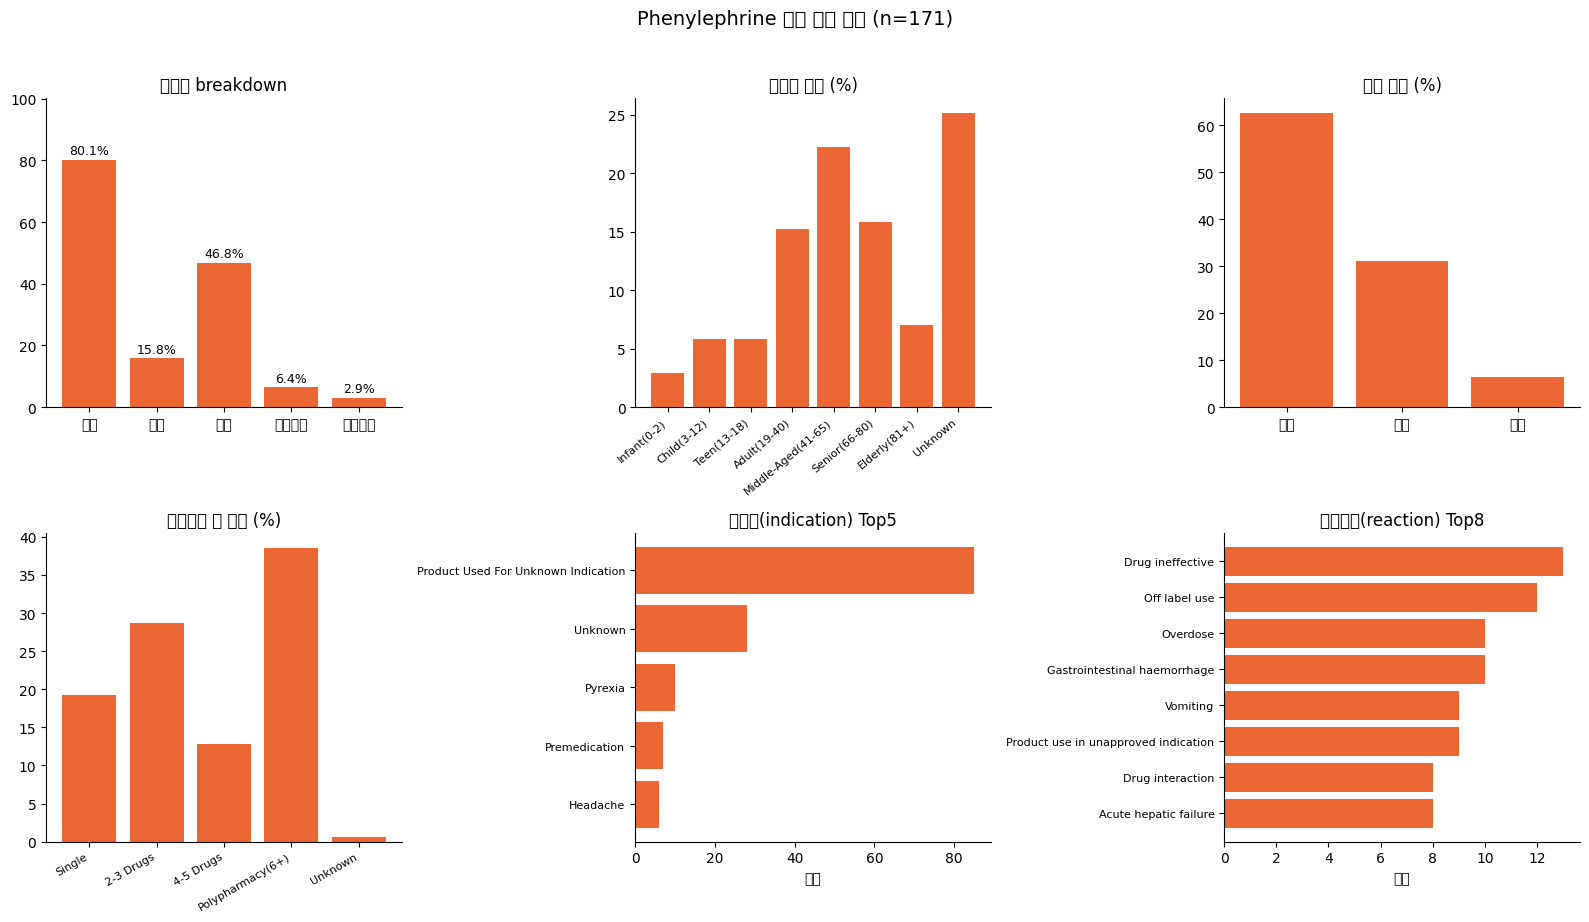

In [11]:
sub = groups['Phenylephrine']
print('병용약물 수:', sub['drug_count_category'].value_counts().to_dict())
print('적응증 Top5:', sub['drug_indication'].value_counts().head(5).to_dict())
print('연도별 건수:', sub['quarter'].str[:4].value_counts().sort_index().to_dict())

plot_group_dashboard('Phenylephrine', sub, colors['Phenylephrine'])


**대시보드 6개 그래프별 인사이트**

① **중증도 breakdown** — 심각 80.1%·사망 15.8%로 세 그룹 중 최고, 생명위협 6.4%·후유장애 2.9%도 유일하게 0%가 아닙니다. 즉 **경증부터 사망까지 위해 스펙트럼이 세 그룹 중 가장 넓게** 퍼져 있습니다.

② **연령대 분포** — Unknown이 최다(25.1%)이지만, 특정 가능한 연령대 중 Middle-Aged(22.2%)+Senior(15.8%)+Elderly(7.0%) = 41세 이상이 45%를 차지합니다. 심혈관 위험이 상대적으로 높은 연령군의 비중이 상당합니다.

③ **성별 분포** — 여성 62.6%·남성 31.0%·Unknown 6.4%. 세 그룹 중 Unknown 비중이 가장 낮아 상대적으로 인구통계 기록이 양호한 편입니다.

④ **병용약물 수 분포** — Polypharmacy(6+)가 38.6%로 최다지만 Single(단독복용)도 19.3%로 상당수 — **감기약을 자가치료로 단독 복용한 건강한 성인군**과 **다른 약물을 이미 복용 중인 만성질환자군**이 한 조합 안에 섞여 있습니다.

⑤ **적응증 Top5** — Unknown 계열(Product Used For Unknown Indication 49.7% + Unknown 16.4%) = 66.1%로 압도적입니다. 특정 가능한 것 중에는 Pyrexia(발열, 5.8%)·Premedication(4.1%)이 상위권입니다.

⑥ **이상반응 Top8** — "Drug ineffective"(약효 없음)가 1위입니다. Off label use·Overdose·GI haemorrhage가 뒤를 이어, **"효과가 없다고 느껴서 더 많이/다르게 먹는" 악순환 가능성**을 보여줍니다.

**왜 이런 패턴이 나타날까? (기전)**
- *적응증 미상 66%(⑤)*: 페닐에프린 조합은 처방전 없이 스스로 골라 먹는 **완전 자가선택(self-selection) OTC 제품**입니다. 코막힘·기침·몸살이 뒤섞인 다증상 완화 목적으로 "그냥 감기약"으로 구매하는 경우가 대부분이라, 소비자가 신고할 때도 정확한 증상을 특정하지 않는 경우가 많습니다 — 약리 기전이 아니라 **다증상 복합제 특유의 사용/보고 행태**입니다.
- *Polypharmacy와 Single의 공존(④)*: 페닐에프린은 단일 비충혈제거정부터 4~5개 활성성분이 든 종합감기약까지 제형 스펙트럼이 넓고, ②에서 본 것처럼 사용 연령대도 젊은 성인부터 심혈관질환을 가진 중장년·고령층까지 폭넓습니다. **알파-1 아드레날린 작용제인 페닐에프린은 혈관수축을 통해 혈압을 올릴 수 있어 심혈관질환자에게 금기·주의 대상**인데, 이런 환자군은 이미 강압제 등을 복용 중이므로 병용약물 수가 자연히 높아지는 반면, 건강한 성인의 단순 감기 자가치료는 단독복용으로 남아 두 패턴이 동시에 나타납니다.
- *"Drug ineffective" 최다(⑥)*: 이는 우연이 아니라, 2023년 9월 FDA 비처방약자문위원회(NDAC)가 **경구 페닐에프린이 권장 용량에서 비충혈제거제로서 효과가 없다는 데이터**를 만장일치로 인정한 사건과 직접 연결됩니다. 경구 복용 시 장·간에서 대부분 대사되어 생체이용률이 1% 미만이기 때문에, 애초에 약리학적으로 충분한 혈중농도에 도달하기 어렵습니다. FDA는 2024년 11월 경구 페닐에프린을 OTC 모노그래프에서 제외하는 규정안을 발표했습니다. "효과 없음"을 느낀 소비자가 권장량 이상을 복용(Overdose 10건)하면서 위장관 출혈 등 다른 이상반응으로 이어졌을 가능성도 있습니다.
- *심혈관 위험군 비중(②)*: 혈관수축 기전 자체가 고혈압·부정맥 환자에게 위험하기 때문에, 이 연령군에서 사용/보고가 상대적으로 많이 나타나는 것은 페닐에프린의 약리적 금기 프로파일과 직접 연결됩니다.


### 5.3 Acetaminophen + Dextromethorphan (n=36)

/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

병용약물 수: {'Single': 22, '2-3 Drugs': 7, 'Polypharmacy(6+)': 5, '4-5 Drugs': 2}
적응증 Top5: {'Product Used For Unknown Indication': 12, 'Pain': 4, 'Pyrexia': 3, 'Headache': 3, 'Hypersensitivity': 2}
연도별 건수: {'2015': 4, '2016': 1, '2017': 2, '2018': 2, '2019': 25, '2022': 1, '2024': 1}


/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

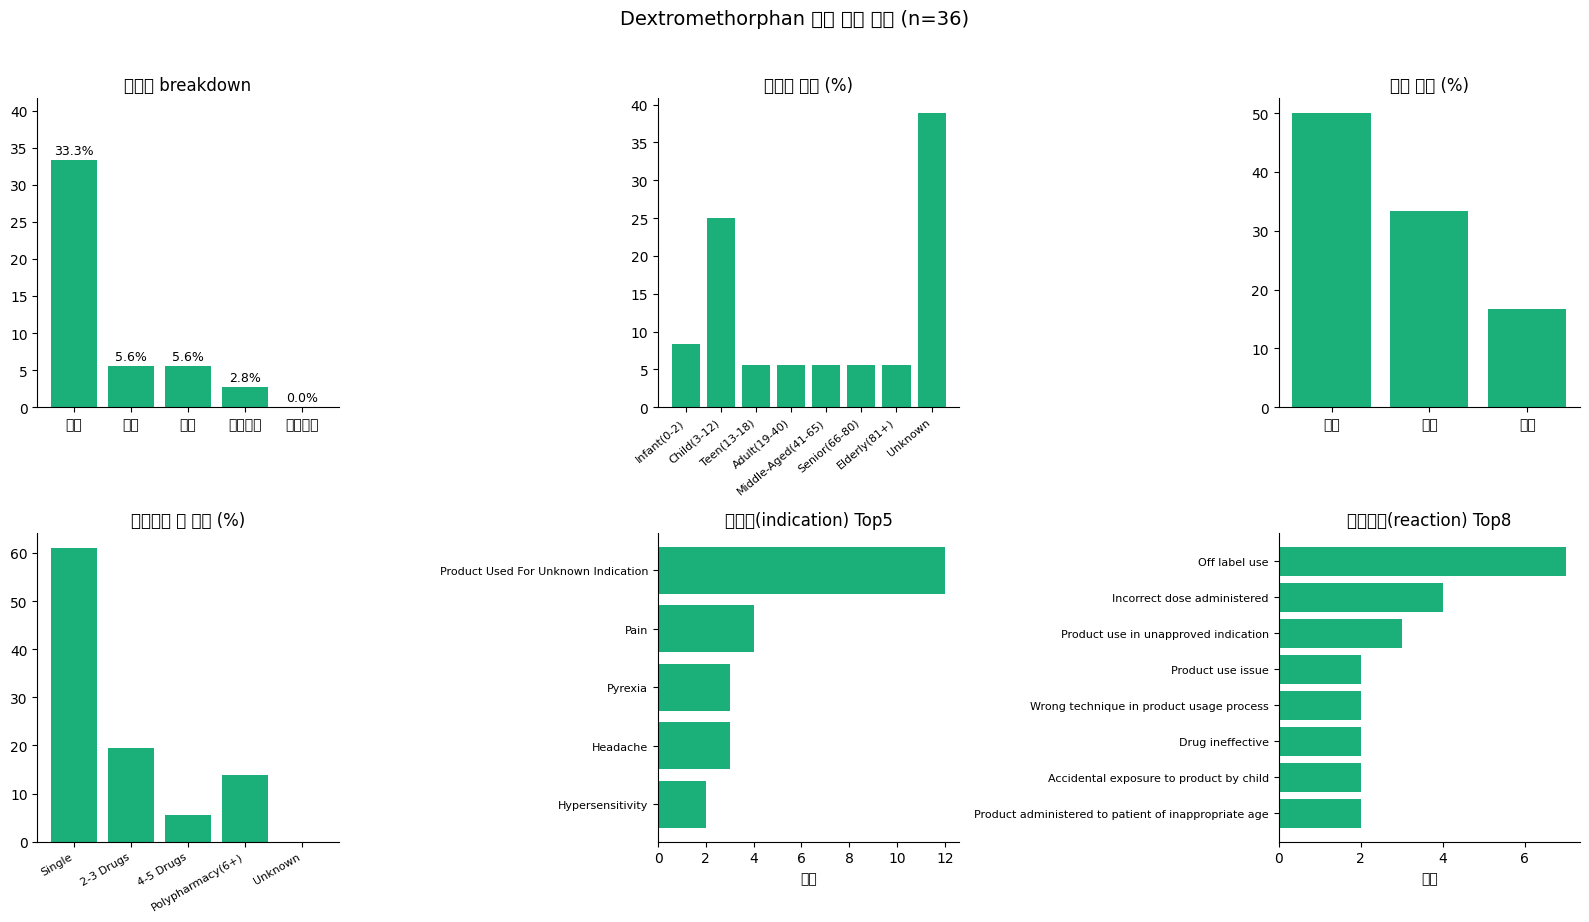

In [12]:
sub = groups['Dextromethorphan']
print('병용약물 수:', sub['drug_count_category'].value_counts().to_dict())
print('적응증 Top5:', sub['drug_indication'].value_counts().head(5).to_dict())
print('연도별 건수:', sub['quarter'].str[:4].value_counts().sort_index().to_dict())

plot_group_dashboard('Dextromethorphan', sub, colors['Dextromethorphan'])


**대시보드 6개 그래프별 인사이트**

① **중증도 breakdown** — 심각 33.3%·사망 5.6%·입원 5.6%로 다섯 지표 전부 세 그룹 중 최저입니다. 세 조합 중 가장 경한 위해 프로파일을 보입니다.

② **연령대 분포** — Child(3-12) 25.0% + Infant(0-2) 8.3% = 33.3%가 소아이며, Unknown(38.9%)을 제외한 성인 연령대(Adult·Middle-Aged·Senior·Elderly·Teen)는 각각 5.6%씩 고르게 분산되어 있습니다. 즉 **소아가 특정 가능한 연령대 중 압도적 최다**입니다.

③ **성별 분포** — 여성 50.0%·남성 33.3%·Unknown 16.7%로, 세 그룹 중 Unknown 비중이 가장 높습니다.

④ **병용약물 수 분포** — Single(단독복용) 61.1%로 세 그룹 중 유일하게 과반을 차지합니다.

⑤ **적응증 Top5** — Unknown(33.3%) > Pain(11.1%) ≈ Headache(8.3%) ≈ Pyrexia(8.3%), 그리고 **"Accidental Exposure To Product"(5.6%)가 Top5에 진입한 유일한 그룹**입니다.

⑥ **이상반응 Top8** — "Off label use"(1위)에 이어 "Incorrect dose administered", "Product use in unapproved indication" 등 **투약오류·오사용 계열이 상위 전체를 장악**합니다. 약물 자체의 부작용보다 "잘못 쓴 것"이 핵심 문제입니다.

**왜 이런 패턴이 나타날까? (기전)**
- *단독복용 61.1%(④)*: 이 조합의 주 사용자층이 **기저질환이 거의 없는 소아·영유아**이기 때문입니다(②). 성인처럼 혈압약·항응고제 등 만성질환약을 병용할 일이 적고, 부모가 "기침감기약 한 가지만" 먹이는 경우가 많아 병용약물 수 자체가 구조적으로 낮게 나타납니다. 이는 덱스트로메토르판의 약리작용이 아니라 **사용자 모집단(소아)의 낮은 동반질환 부담**에서 기인한 인구학적 결과입니다.
- *우발적 노출(⑤)*: 덱스트로메토르판 함유 제품은 소아용으로 **달콤한 시럽·향 첨가 액상 제형**으로 만들어지는 경우가 많아, 아이들이 사탕/음료로 착각해 스스로 열어 마시는 사고가 발생하기 쉽습니다. 여기에 **덱스트로메토르판 자체가 NMDA 수용체 길항·시그마-1 작용을 가진 중추신경 활성 물질**이라, 소량이라도 노출되면 진정·환각 등 반응이 나타날 수 있어 실제 이상사례로 이어집니다 — 제형(액상·매력적 포장)과 약리학(중추신경 작용)이 함께 만드는 위험입니다.
- *투약오류 계열 집중(⑥)*: ②의 소아 중심 사용자층과 직결됩니다. 소아는 체중별로 용량을 환산해야 하는데, 액상 계량 오류·연령 misjudge·연속 투여 등 **보호자의 투약 과정 자체에서 오류가 발생하기 쉬운 구조**입니다. 반면 디펜히드라민·페닐에프린 그룹처럼 성분 자체의 약리적 중증 반응(간독성, 심혈관 부담)이 아니라, "얼마나 정확히 먹였는가"라는 사용 과정의 문제가 이상반응의 핵심 축이 되는 점이 이 그룹의 가장 큰 차별점입니다.
- *중증도 최저(①)*: ④~⑥에서 확인되듯 이 그룹의 문제는 대부분 **경미한 투약오류/오사용**이지 중독성 장기손상이 아니기 때문에, 사망·생명위협·후유장애로 이어지는 비율이 구조적으로 낮게 나타납니다.


---

## 6. 세 그룹이 다른 이유 — 도메인 지식

세 조합은 모두 아세트아미노펜(해열진통제)을 기반으로 하지만, 함께 들어간 부성분의 약리학적 특성과 대상 적응증이 완전히 다르기 때문에 이상사례 패턴도 다르게 나타납니다.

### 기전 비교: 수용체 표적과 위해가 만들어지는 경로

세 부성분은 **몸의 서로 다른 수용체**에 작용하고, 그 결과 **서로 다른 방식으로 "과다 노출"에 이르는 경로**를 만듭니다. 아래 표로 정리하면 이번 분석에서 본 이상반응 차이가 왜 나타나는지 한눈에 연결됩니다.

| 조합 | 주요 작용 수용체/경로 | 1차 약리 효과 | 위해로 이어지는 경로 |
|---|---|---|---|
| Diphenhydramine | **H1 히스타민 수용체 길항**(중추, BBB 통과) + **무스카린 아세틸콜린 수용체 길항**(항콜린) + 과량 시 심장 Na⁺ 채널 차단 | 진정·졸림, 입마름·변비·요폐 등 항콜린 증상, 과량 시 부정맥 | 진정 효과를 "수면 보조"로 상시 이용 → 주간/야간 제품 이중 복용 → 아세트아미노펜 누적 → **간독성**(지연형) |
| Phenylephrine | **알파-1 아드레날린 수용체 작용**(말초 혈관 평활근) | 혈관수축(비강 점막 부종 감소 + 전신 혈압 상승) | 경구 복용 시 장·간에서 대부분 대사되어 **생체이용률 1% 미만** → 효과 미체감 → 반복/과다 복용 → **위장관 출혈·심혈관 부담·"약효 없음" 보고** |
| Dextromethorphan | **NMDA 수용체 길항** + **시그마-1 수용체 작용**(+ 고용량 시 세로토닌 재흡수 억제) | 연수 기침 중추 억제(진해), 고용량 시 해리성·환각 효과 | 소아용 **액상·가향 제형** → 계량 오류·우발적 노출 → 중추신경 노출 사고, 청소년 이상에서는 남용("robotripping") |

**공통 분모 — 아세트아미노펜 자체의 기전**: 세 조합 모두 아세트아미노펜은 간에서 CYP2E1 효소에 의해 소량이 **NAPQI**(반응성 대사산물)로 전환되는데, 정상 용량에서는 글루타치온이 이를 즉시 해독합니다. 그러나 총 섭취량이 하루 4g을 넘으면 글루타치온이 고갈되어 NAPQI가 간세포를 직접 파괴합니다(급성 간부전의 공통 기전). 세 그룹의 차이는 **"어떻게 이 4g 한계를 넘기게 되는가"**에 있습니다:
- Diphenhydramine 조합 → 진정 효과 때문에 인지하지 못한 채 **중복 복용**으로 넘김
- Phenylephrine 조합 → 낮은 생체이용률 때문에 **효과를 위해 의도적으로 초과 복용**하며 넘김
- Dextromethorphan 조합 → 소아의 **우발적 대량 섭취**로 넘김(다만 이 그룹은 성인용 두 그룹보다 전체 중증도가 낮게 나타남 — 소아 1회 우발 노출은 성인의 반복적 만성 중복복용보다 총 노출량 자체는 적은 경우가 많기 때문으로 추정됩니다)

즉 세 그룹의 이상사례 프로파일이 다른 것은 "아세트아미노펜이 다르게 작용해서"가 아니라, **부성분의 수용체 작용이 사용자의 복용 행동(반복 복용/과다 복용/우발적 노출)을 서로 다른 방향으로 유도하고, 그 결과 동일한 간독성 기전에 도달하는 경로가 갈리기 때문**입니다.

### Acetaminophen + Diphenhydramine (예: Tylenol PM, Percogesic)

디펜히드라민은 **1세대(진정성) 항히스타민제**로, 뇌혈관장벽을 통과해 강한 진정·항콜린 작용을 일으킵니다. "야간용(PM)" 통증완화제로 설계되어 있어, 데이터에서도 적응증이 수면장애·불면증에 몰려 있고 연령대는 중장년~고령층(평균 55.7세) 중심입니다.

- **급성 간부전이 최다 이상반응(5/14)** — 아세트아미노펜 자체의 간독성 특성상 "수면제"로 오인해 반복·과량 복용하거나, 이미 아세트아미노펜을 포함한 다른 진통제와 중복 복용(therapeutic duplication)하면서 총 섭취량이 최대안전용량(4g/일)을 넘는 경우가 실제 임상에서 흔히 보고됩니다.
- 고령층에서는 디펜히드라민의 **항콜린 부담(anticholinergic burden)**이 인지기능저하, 낙상, 요폐 등 위험을 높인다는 것이 미국노년의학회(AGS) Beers Criteria의 핵심 근거이며, 2023년 개정판에서도 65세 이상에게 1세대 항히스타민제(디펜히드라민 포함) 사용을 피하도록 권고합니다.
- 과량 복용 시 디펜히드라민은 **나트륨 채널 차단 작용(삼환계 항우울제 중독과 유사)**으로 부정맥·경련을 유발할 수 있어, 2020년 FDA는 "Benadryl Challenge"(SNS발 다량복용 챌린지)와 관련해 고용량 디펜히드라민의 심장 문제·발작·혼수·사망 위험을 별도 경고했습니다 — 데이터의 "Drug abuse" 보고와 맥락이 일치합니다.

**출처**:
- American Geriatrics Society, [2023 AGS Beers Criteria® for Potentially Inappropriate Medication Use in Older Adults](https://www.americangeriatrics.org/)
- FDA Drug Safety Communication (2020.09.24), ["FDA warns about serious problems with high doses of the allergy medicine diphenhydramine (Benadryl)"](https://www.fda.gov/drugs/drug-safety-and-availability/fda-warns-about-serious-problems-high-doses-allergy-medicine-diphenhydramine-benadryl)

### Acetaminophen + Phenylephrine (예: Tylenol Cold, Panadol Cold & Flu)

페닐에프린은 **알파-1 아드레날린 작용제(혈관수축제)**로 코점막 비충혈 목적의 감기약에 광범위하게 쓰입니다. 세 그룹 중 표본 수가 가장 많고(171건), 사망률(15.8%)과 생명위협 비율(6.4%)도 가장 높게 나타났습니다.

- **"Drug ineffective"(약효 없음)가 최다 보고 사유(13건)**인 점이 특히 주목할 만합니다 — 이는 우연이 아니라, 2023년 9월 FDA 비처방약자문위원회(NDAC)가 경구 페닐에프린이 권장 용량에서 비충혈제거제로서 효과가 없다는 데이터를 만장일치로 인정한 사건과 직접 연결됩니다. 경구 복용 시 장·간에서 대부분 대사되어 생체이용률이 1% 미만으로 알려져 있습니다. FDA는 2024년 11월 경구 페닐에프린을 OTC 모노그래프에서 제외하는 규정안(proposed order)을 발표했습니다.
- 혈관수축 작용 때문에 페닐에프린은 **고혈압·부정맥·심혈관질환자에게 금기 또는 주의**가 필요한 성분입니다. 이 그룹의 평균 연령(47.3세)과 중장년~고령층 비중이 높은 것은 심혈관 위험이 있는 인구집단에서 실제로 더 많이 사용/보고된다는 정황과 부합합니다.
- 위장관 출혈(GI haemorrhage, 10건) 비중이 높은 것은 감기약 복합제에 흔히 동반되는 NSAID/아스피린 병용이나 고용량 아세트아미노펜 복용과 연관될 가능성이 있습니다.

**출처**:
- FDA, [Nonprescription Drugs Advisory Committee Meeting Briefing Document, Oral Phenylephrine](https://www.fda.gov/media/172701/download) (2023.09.11-12)
- CNN (2024.11.07), ["FDA moves to pull popular decongestant from shelves amid effectiveness concerns"](https://www.cnn.com/2024/11/07/health/fda-decongestant-phenylephrine-effectiveness-concerns)

### Acetaminophen + Dextromethorphan (예: Children's Tylenol Cold, Coricidin)

덱스트로메토르판은 **중추성 진해제(NMDA 수용체 길항 / 시그마-1 작용)**로 어린이용 감기·기침약에 많이 배합됩니다. 세 그룹 중 중증도가 가장 낮고(심각 33.3%, 사망 5.6%), 소아·영유아 비중이 뚜렷합니다.

- 상위 이상반응이 **"부정확한 용량 투여", "부적절한 연령대 투여", "소아의 우발적 노출"** 등 오남용·투약오류 계열로 채워져 있는 점이 특징입니다. 이는 실제 소아 기침감기약의 핵심 위험으로 지적되어 온 문제입니다.
- 2007~2008년 FDA 비처방약자문위원회 및 소아자문위원회는 **2세 미만 영유아에게 OTC 기침감기약(덱스트로메토르판 포함) 사용을 금지**할 것을 권고했고, 이후 제조사들이 자발적으로 **"4세 미만 사용금지"** 라벨 변경에 나섰습니다 — 효과 근거 부족과 과량·오용 위험이 근거였습니다.
- 반대로 청소년~성인 구간에서는 덱스트로메토르판 특유의 **남용("robotripping", DXM misuse)** 위험이 존재합니다. 다만 이번 데이터셋에서는 소아 오투약 신호가 더 두드러집니다.
- 이 그룹은 평균 병용약물 수(2.9개)가 세 그룹 중 가장 적어 다약제 병용(polypharmacy) 배경이 옅은, 비교적 건강한 소아·단일제제 사용자 중심임을 시사합니다.

**출처**:
- FDA Consumer Update, ["Should You Give Kids Medicine for Coughs and Colds?"](https://www.fda.gov/consumers/consumer-updates/should-you-give-kids-medicine-coughs-and-colds)
- Federal Register (2008), ["Over-the-Counter Cough and Cold Medications for Pediatric Use"](https://www.federalregister.gov/documents/2008/08/25/E8-19657/over-the-counter-cough-and-cold-medications-for-pediatric-use-notice-of-public-hearing)
- Stop Medicine Abuse / Poison Control, [Dextromethorphan (DXM) Abuse & Warning Signs](https://stopmedicineabuse.org/about-dxm-abuse/)

### 종합 인사이트

세 조합의 부성분은 각각 **진정/항콜린(디펜히드라민) → 혈관수축(페닐에프린) → 중추진해(덱스트로메토르판)**로 약리 기전이 전혀 다르고, 이것이 이상사례 패턴을 결정짓는 핵심 변수입니다.

| 조합 | 수용체 기전 | 핵심 위험 신호 | 배경 |
|---|---|---|---|
| Diphenhydramine | H1/무스카린 길항 (중추 진정) | 간독성·의도적 과량복용 | 고령층 + 진정제로 오인한 반복복용 |
| Phenylephrine | 알파-1 작용 (말초 혈관수축) | "약효 없음" 최다 보고 | 최대 표본, 2023년 FDA 무효성 판정과 일치 |
| Dextromethorphan | NMDA 길항/시그마-1 작용 (중추 진해) | 투약오류·연령 부적합 사용 | 소아 사용 비중 높음, 전반적 중증도는 최저 |

세 그룹 모두 아세트아미노펜을 공유하므로 **중복복용으로 인한 간독성**은 공통 위험 요인이지만, "무엇 때문에 이 조합을 복용했고, 어떤 인구집단이 사용했는가"에 따라 위해 양상이 갈린다는 것이 이 비교의 핵심입니다.

---

**데이터 출처**: FDA FAERS(Adverse Event Reporting System) 기반 아세트아미노펜 51개 브랜드 매핑 데이터셋(사용자 제공 CSV). 그룹 분류는 `전체_활성성분` 컬럼에서 대상 조합 문자열을 포함하는 행을 필터링해 산출했습니다.

**주의사항**: 이 분석은 FAERS 자발보고 데이터 기반으로 인과관계를 증명하지 않으며, 보고 편향(중증·분쟁 사례 과대표집)이 존재할 수 있습니다. 각 조합군의 표본 크기(n=14, 171, 36)가 상이하여 비율 비교 시 신뢰구간을 고려해야 하며, 특히 Diphenhydramine 그룹(n=14)의 수치는 방향성 참고용으로만 해석해야 합니다.


---

# Part 2. 아세트아미노펜 2종 신규 복합제 비교 분석

아래 2개 조합을 비교합니다.

- **Acetaminophen + Chlorpheniramine + Dextromethorphan** — 예: Coricidin HBP Cold and Flu, Children's Tylenol Cold Plus Flu (소아용 감기·기침약)
- **Acetaminophen + Aspirin + Caffeine** — 예: Excedrin Migraine, Excedrin Extra Strength, Goody's Extra Strength (편두통·두통 전용 진통제)

두 조합 모두 아세트아미노펜을 포함한 3성분 복합제이지만, 함께 배합된 부성분의 약리 기전과 대상 적응증이 전혀 달라 이상사례 패턴에도 뚜렷한 차이가 나타납니다.

**필터링 방식**: 3성분 조합은 브랜드마다 성분 표기 순서가 다르게 나타납니다(예: `Aspirin + Acetaminophen + Caffeine` vs `Acetaminophen + Aspirin + Caffeine`, `Dextromethorphan + Chlorpheniramine` vs `Chlorpheniramine + Dextromethorphan`). 따라서 단순 문자열 포함(`str.contains`) 대신, 각 브랜드 세그먼트의 성분을 **순서 무관 집합(set)**으로 정규화한 뒤 비교합니다.

> **참고**: 두 그룹은 서로 겹치지 않습니다(교집합 0건).


In [13]:
# --- Part 2: 2종 복합제 그룹 필터링 -----------------------------------------
def parse_segments(cell):
    """'브랜드1: 성분A + 성분B; 브랜드2: 성분C' -> [{'성분A','성분B'}, {'성분C'}]"""
    segments = []
    for seg in re.split(r';\s*', str(cell)):
        if ':' not in seg:
            continue
        comp = seg.split(':', 1)[1]
        comp = re.sub(r'\([^)]*\)', '', comp)         # 괄호 주석 제거: (서방형), (아스피린 미포함...) 등
        comp = re.sub(r'\d+(\.\d+)?\s*mg', '', comp)   # 용량(mg) 표기 제거
        ingredients = {p.strip() for p in comp.split('+') if p.strip()}
        segments.append(ingredients)
    return segments

df['_성분세그먼트'] = df['전체_활성성분'].apply(parse_segments)

def has_exact_combo(segments, target):
    return any(seg == target for seg in segments)

combos2 = {
    'Chlorpheniramine_Dextromethorphan': {'Acetaminophen', 'Chlorpheniramine', 'Dextromethorphan'},
    'Aspirin_Caffeine': {'Acetaminophen', 'Aspirin', 'Caffeine'},
}
colors2 = {
    'Chlorpheniramine_Dextromethorphan': '#c0392b',
    'Aspirin_Caffeine': '#16a085',
}

groups2 = {}
for name, target in combos2.items():
    mask = df['_성분세그먼트'].apply(lambda segs: has_exact_combo(segs, target))
    groups2[name] = df[mask].copy()

for name, sub in groups2.items():
    print(f'{name:<35} n={len(sub):>4}  (전체의 {len(sub)/len(df)*100:.1f}%)')


Chlorpheniramine_Dextromethorphan   n=  28  (전체의 2.2%)
Aspirin_Caffeine                    n=  26  (전체의 2.1%)


## 7. 중증도 지표 비교 (Part 2)


In [14]:
summary_rows2 = []
for name, sub in groups2.items():
    summary_rows2.append({
        '조합': name,
        'n': len(sub),
        '심각(%)': round((sub['serious'] == 'Yes').mean() * 100, 1),
        '사망(%)': round(sub['is_fatal'].mean() * 100, 1),
        '입원(%)': round(sub['is_hospitalized'].mean() * 100, 1),
        '생명위협(%)': round(sub['is_life_threat'].mean() * 100, 1),
        '후유장애(%)': round(sub['is_disabling'].mean() * 100, 1),
        '회복(%)': round(sub['patient_recovered'].mean() * 100, 1),
    })
summary_df2 = pd.DataFrame(summary_rows2).set_index('조합')
summary_df2


,n,심각(%),사망(%),입원(%),생명위협(%),후유장애(%),회복(%)
조합,,,,,,,
Chlorpheniramine_Dextromethorphan,28,17.9,7.1,3.6,3.6,0.0,3.6
Aspirin_Caffeine,26,26.9,0.0,11.5,0.0,0.0,15.4


/tmp/ipykernel_1733/216560579.py:18: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/216560579.py:18: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/216560579.py:18: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/216560579.py:18: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/216560579.py:18: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/216560579.py:18: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/216560579.py:18: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

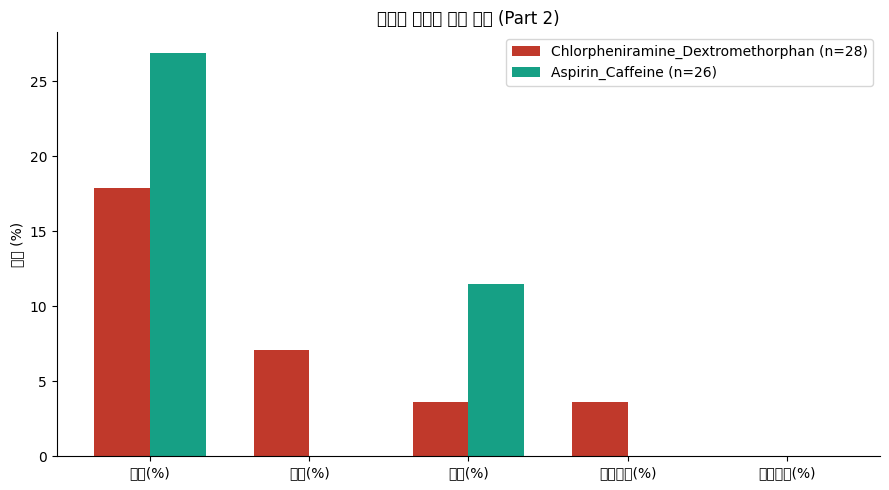

In [15]:
metrics = ['심각(%)', '사망(%)', '입원(%)', '생명위협(%)', '후유장애(%)']
x = np.arange(len(metrics))
width = 0.35
n_groups = len(groups2)

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(groups2.keys()):
    offset = (i - (n_groups - 1) / 2) * width
    vals = summary_df2.loc[name, metrics].values
    ax.bar(x + offset, vals, width, label=f'{name} (n={len(groups2[name])})', color=colors2[name])

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('비율 (%)')
ax.set_title('조합별 중증도 지표 비교 (Part 2)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**관찰**: 두 조합 모두 다른 그룹들에 비해 중증도가 낮은 편이지만, 서로 다른 방식으로 낮습니다. Chlorpheniramine+Dextromethorphan 조합은 심각 17.9%·사망 7.1%·입원 3.6%로 다섯 지표 모두 낮지만 사망·생명위협은 0%가 아닙니다(드물지만 치명적인 사례 존재). 반면 Aspirin+Caffeine 조합은 심각 26.9%로 '심각' 판정 비율 자체는 더 높지만 사망·생명위협·후유장애는 모두 0%입니다 — **심각 판정은 받아도 치명적 결과로 이어지는 경우는 없는 '경증-다발형' 패턴**입니다.


## 8. 연령대 · 성별 분포 (Part 2)


/tmp/ipykernel_1733/4256135746.py:18: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4256135746.py:18: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4256135746.py:18: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4256135746.py:18: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4256135746.py:18: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4256135746.py:18: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/4256135746.py:18: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_lay

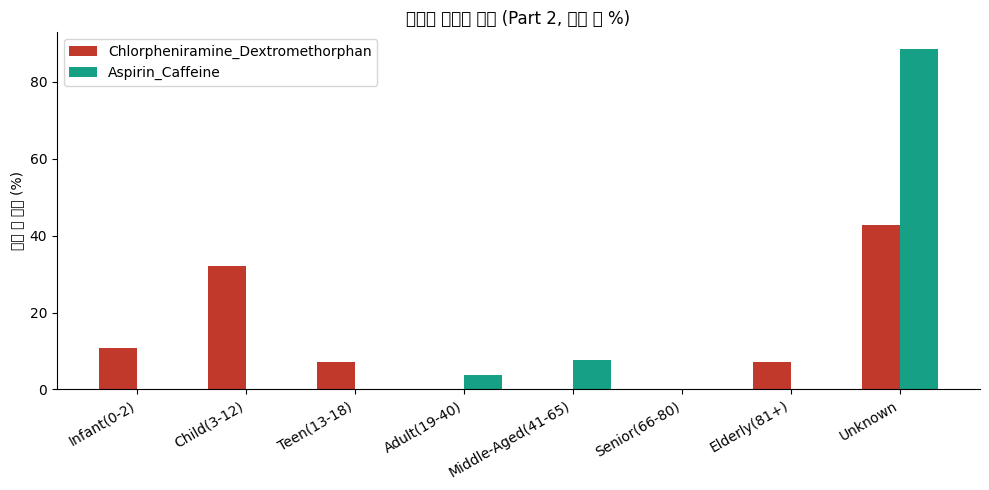

In [16]:
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']

fig, ax = plt.subplots(figsize=(10, 5))
xw = np.arange(len(age_order))
for i, (name, sub) in enumerate(groups2.items()):
    offset = (i - (len(groups2) - 1) / 2) * width
    counts = sub['age_group'].value_counts()
    pct = [counts.get(a, 0) / len(sub) * 100 for a in age_order]
    ax.bar(xw + offset, pct, width, label=name, color=colors2[name])

ax.set_xticks(xw)
ax.set_xticklabels(age_order, rotation=30, ha='right')
ax.set_ylabel('그룹 내 비율 (%)')
ax.set_title('조합별 연령대 분포 (Part 2, 그룹 내 %)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1733/2042142610.py:18: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2042142610.py:18: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2042142610.py:18: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2042142610.py:18: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2042142610.py:18: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2042142610.py:18: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2042142610.py:18: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  plt.tight

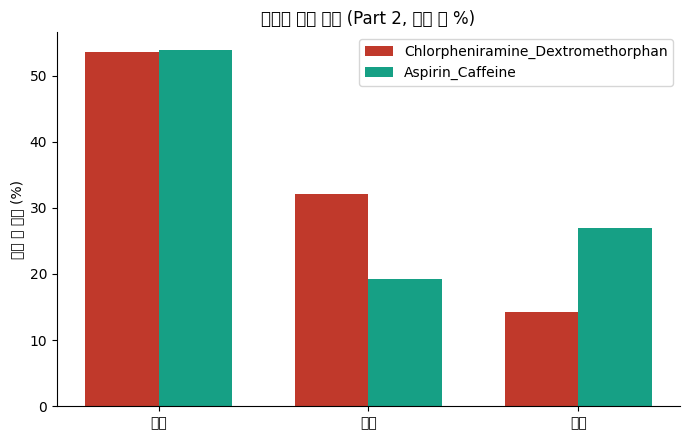

In [17]:
sex_order = ['Female', 'Male', 'Unknown']
sex_labels_ko = {'Female': '여성', 'Male': '남성', 'Unknown': '미상'}

fig, ax = plt.subplots(figsize=(7, 4.5))
xs = np.arange(len(sex_order))
for i, (name, sub) in enumerate(groups2.items()):
    offset = (i - (len(groups2) - 1) / 2) * width
    counts = sub['patient_sex'].value_counts()
    pct = [counts.get(s, 0) / len(sub) * 100 for s in sex_order]
    ax.bar(xs + offset, pct, width, label=name, color=colors2[name])

ax.set_xticks(xs)
ax.set_xticklabels([sex_labels_ko[s] for s in sex_order])
ax.set_ylabel('그룹 내 비율 (%)')
ax.set_title('조합별 성별 분포 (Part 2, 그룹 내 %)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**관찰**: Chlorpheniramine+Dextromethorphan 조합은 Child(3-12) 32.1%+Infant(0-2) 10.7%=42.8%가 영유아·소아이며 평균연령 16.2세로, 소아용 감기약이라는 제품 특성이 그대로 드러납니다. Aspirin+Caffeine 조합은 Unknown이 88.5%로 매우 높지만 특정 가능한 연령대는 전부 성인(Middle-Aged 7.7%·Adult 3.8%)이며 평균연령 51.0세로, 편두통 치료 목적의 중장년 사용자 중심임을 시사합니다 — 두 그룹의 평균연령 차이(16.2세 vs 51.0세)가 제품 용도의 차이를 그대로 반영합니다. 성별은 두 그룹 모두 여성 비율이 남성보다 높습니다(53.6%, 53.8%).


## 9. 조합별 상위 이상반응(Reaction) (Part 2)


/tmp/ipykernel_1733/2698241232.py:10: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2698241232.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


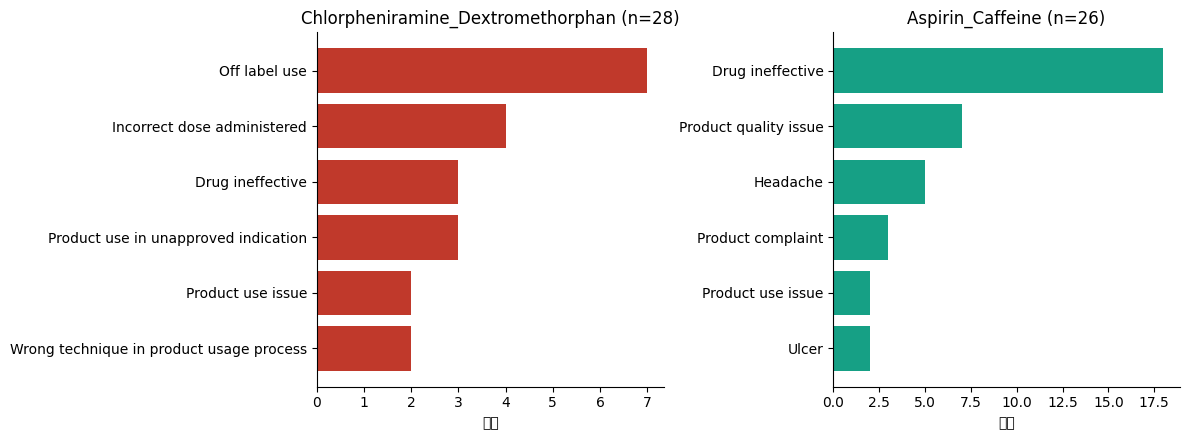

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, sub) in zip(axes, groups2.items()):
    rx = top_reactions(sub)
    labels = [r[0] for r in rx][::-1]
    vals = [r[1] for r in rx][::-1]
    ax.barh(labels, vals, color=colors2[name])
    ax.set_title(f'{name} (n={len(sub)})')
    ax.set_xlabel('건수')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**관찰**:
- **Chlorpheniramine_Dextromethorphan**: Off label use(25.0%)·Incorrect dose administered(14.3%)·Product use in unapproved indication(10.7%)·Accidental exposure to product by child(7.1%) 등 상위 항목 대부분이 투약오류·오용 계열로, 소아용 감기약의 전형적 위험 신호입니다.
- **Aspirin_Caffeine**: Drug ineffective(69.2%)·Product quality issue(26.9%)가 압도적 1·2위입니다. 아래 도메인 지식에서 다루는 2016년 리콜 사건과 시기적으로 연결됩니다.

두 그룹의 이상반응 프로필은 극명하게 갈립니다 — 하나는 **오용·투약오류**가, 다른 하나는 **효과·품질 불만**이 지배적입니다.


---

## 10. 그룹별 단독 심층 분석 (Part 2)

Part 1과 동일한 `plot_group_dashboard` 함수를 재사용해 두 그룹을 하나씩 살펴봅니다.


### 10.1 Acetaminophen + Chlorpheniramine + Dextromethorphan (n=28)


/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

병용약물 수: {'Single': 21, '2-3 Drugs': 6, 'Polypharmacy(6+)': 1}
적응증 Top5: {'Product Used For Unknown Indication': 8, 'Pain': 4, 'Headache': 3, 'Pyrexia': 3, 'Accidental Exposure To Product': 2}
연도별 건수: {'2015': 1, '2017': 1, '2019': 25, '2022': 1}


/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

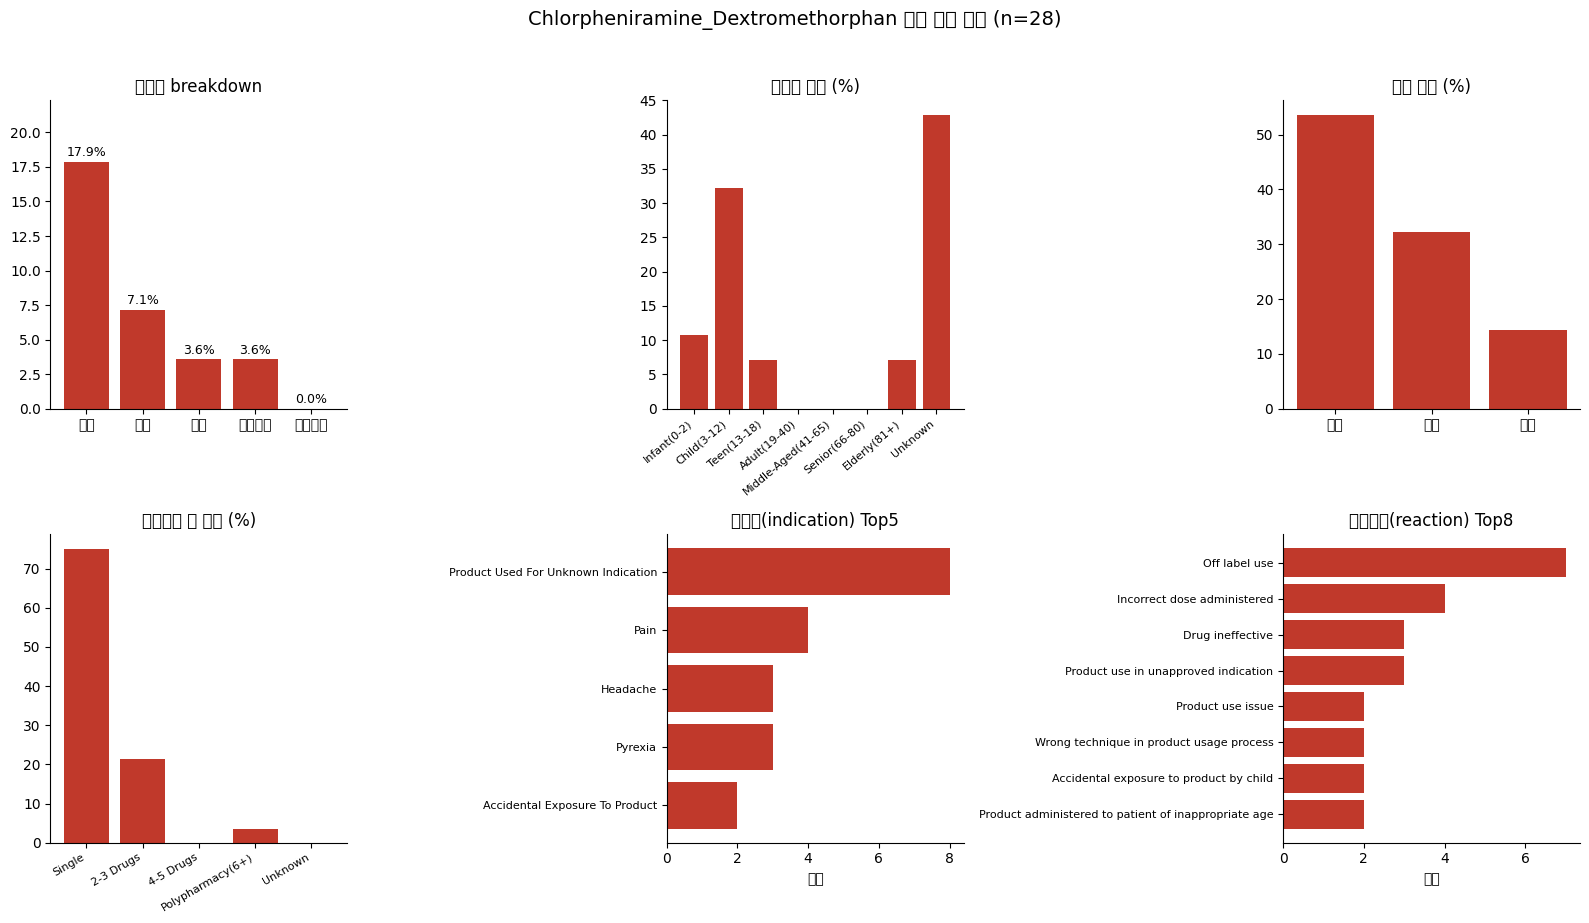

In [19]:
sub = groups2['Chlorpheniramine_Dextromethorphan']
print('병용약물 수:', sub['drug_count_category'].value_counts().to_dict())
print('적응증 Top5:', sub['drug_indication'].value_counts().head(5).to_dict())
print('연도별 건수:', sub['quarter'].str[:4].value_counts().sort_index().to_dict())

plot_group_dashboard('Chlorpheniramine_Dextromethorphan', sub, colors2['Chlorpheniramine_Dextromethorphan'])


**대시보드 6개 그래프별 인사이트**

① **중증도 breakdown** — 심각 17.9%·사망 7.1%·입원 3.6%로, 이 노트북에서 비교한 모든 조합 중 가장 낮은 축에 속합니다(후유장애는 0%).

② **연령대 분포** — Child(3-12) 32.1%+Infant(0-2) 10.7%=42.8%가 영유아·소아이며, 평균연령은 16.2세로 Aspirin+Caffeine 그룹(51.0세)보다 훨씬 낮습니다. Coricidin HBP Cold and Flu, Children's Tylenol Cold Plus Flu 등 소아용 감기약 브랜드로 구성된다는 점과 일치합니다.

③ **성별 분포** — 여성 53.6%·남성 32.1%·Unknown 14.3%로, Aspirin+Caffeine 그룹(Unknown 26.9%)보다는 인구통계 기록이 양호한 편입니다.

④ **병용약물 수 분포** — Single(단독복용) 75.0%로 두 그룹 중 더 높습니다 — 다른 만성질환 약물 없이 감기약 단독으로 복용하는 소아 중심 사용 패턴을 보여줍니다.

⑤ **적응증 Top5** — Product Used For Unknown Indication(28.6%) > Pain(14.3%) ≈ Headache(10.7%) ≈ Pyrexia(10.7%)로, 발열·통증·두통 등 감기 동반 증상이 고르게 나타납니다.

⑥ **이상반응 Top8** — Off label use(25.0%)·Incorrect dose administered(14.3%)·Product use in unapproved indication(10.7%)·Accidental exposure to product by child(7.1%)·Product administered to patient of inappropriate age(7.1%) 등 상위 항목 대부분이 **투약오류·연령 부적합 사용** 계열입니다. 28건 중 25건(89.3%)이 2019년에 집중되어 있어 특정 시기 보고 클러스터일 가능성이 있으나, 정확한 원인은 이 데이터만으로 단정하기 어렵습니다.

**왜 이런 패턴이 나타날까? (기전)**
- *영유아·소아 42.8%(②) — 부성분 설계 자체가 소아 타깃*: 클로르페니라민(1세대 H1 항히스타민, 진정성)과 덱스트로메토르판(NMDA 길항/시그마-1 작용, 중추 진해)은 각각 "콧물·재채기 억제"와 "기침 억제"를 동시에 노리는 조합으로, Coricidin HBP Cold and Flu·Children's Tylenol Cold Plus Flu처럼 처음부터 소아용 감기·기침약으로 설계됩니다. 사용자 모집단이 영유아·소아에 몰리는 것은 우연이 아니라 제품 기획 단계에서 정해진 결과입니다.
- *단독복용 75.0%(④)*: 5.3절의 Dextromethorphan 단독 그룹과 같은 이유입니다 — 주 사용자층인 소아는 만성질환 병용약물이 거의 없어(②), 부모가 감기약 한 가지만 먹이는 경우가 대부분이라 병용약물 수가 구조적으로 낮게 나타납니다.
- *투약오류·오프라벨 계열 집중(⑥)*: 소아용 액상·저작정 제형은 체중별 용량 환산이 필요해 계량 오류가 발생하기 쉽고, Off label use·Incorrect dose administered·Accidental exposure to product by child가 상위를 장악하는 것은 "성분 자체의 독성"이 아니라 "투약 과정에서의 실수"가 핵심 위험 축임을 보여줍니다(Part 1 6장의 Dextromethorphan 기전 참고). 여기에 더해 Coricidin 브랜드는 청소년 사이에서 클로르페니라민+덱스트로메토르판을 동시에 대량 복용하는 "Triple C"/"skittling" 오남용의 대표 대상으로 알려져 있어, Elderly·Teen이 각 7.1% 존재하는 것도 소아 오투약과는 결이 다른 의도적 오남용 경로일 가능성을 시사합니다.
- *중증도 최저(①)*: ④~⑥에서 보듯 이 그룹의 문제 대부분이 경미한 투약오류·오사용이지, 두 부성분의 약리작용(진정·진해) 자체가 간독성처럼 누적성·전신성 손상을 만드는 경로가 아니기 때문에 사망·생명위협·후유장애로 이어지는 비율이 구조적으로 낮게 유지됩니다.


### 10.2 Acetaminophen + Aspirin + Caffeine (n=26)


/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

병용약물 수: {'Single': 18, '2-3 Drugs': 4, 'Polypharmacy(6+)': 2, '4-5 Drugs': 2}
적응증 Top5: {'Migraine': 13, 'Product Used For Unknown Indication': 5, 'Headache': 3, 'Unknown': 2, 'Pain': 2}
연도별 건수: {'2015': 2, '2016': 11, '2017': 5, '2018': 3, '2019': 5}


/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 48337 (\N{HANGUL SYLLABLE BYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50557 (\N{HANGUL SYLLABLE YAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

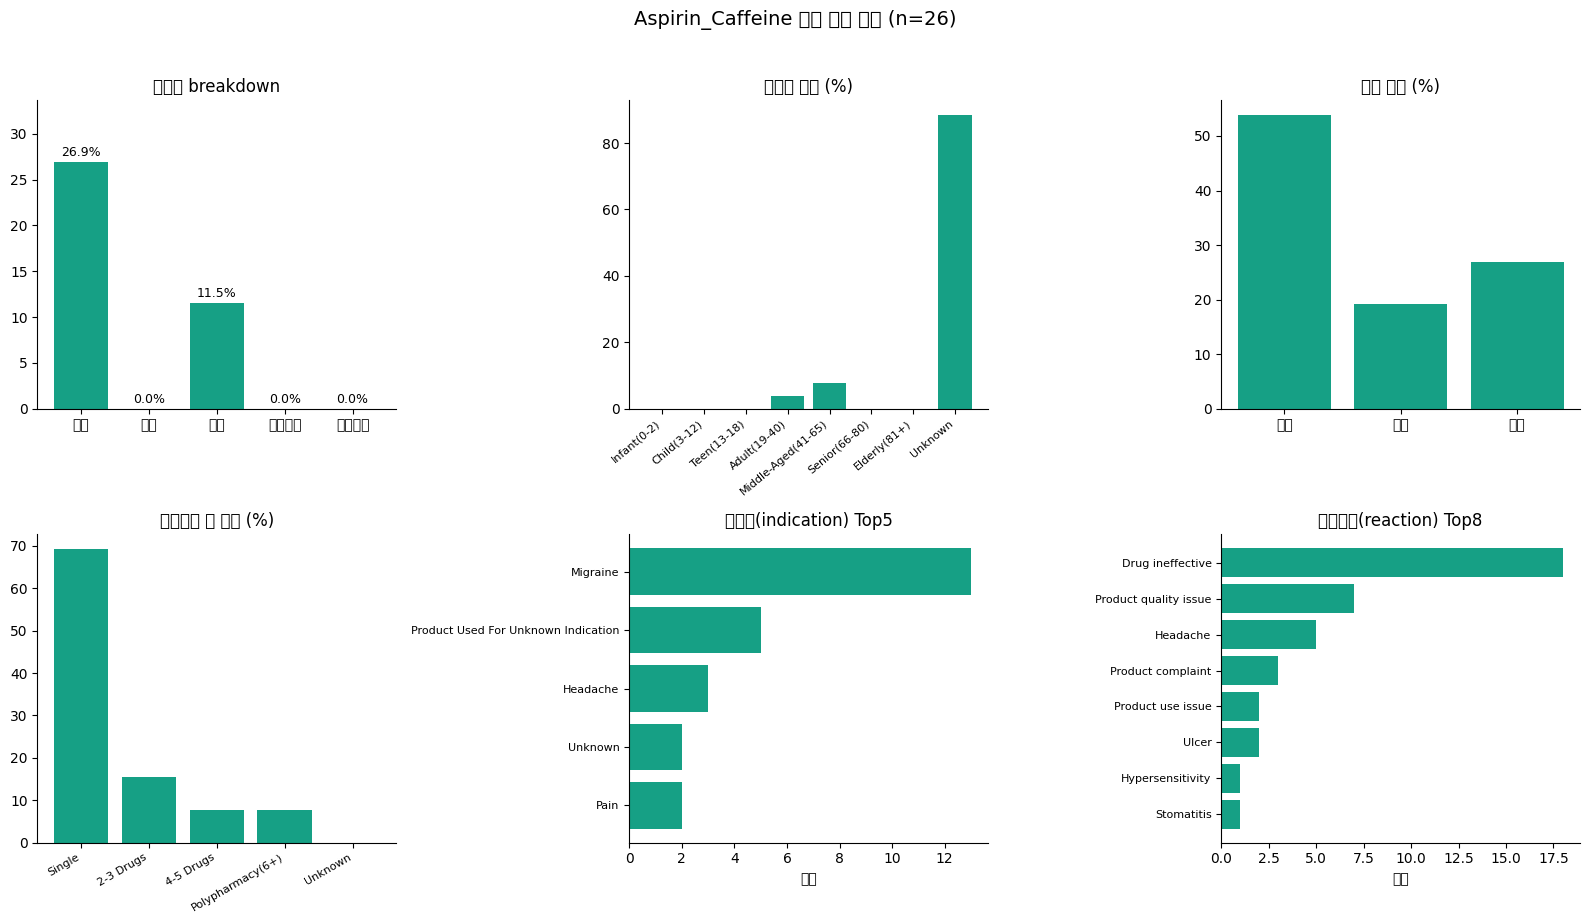

In [20]:
sub = groups2['Aspirin_Caffeine']
print('병용약물 수:', sub['drug_count_category'].value_counts().to_dict())
print('적응증 Top5:', sub['drug_indication'].value_counts().head(5).to_dict())
print('연도별 건수:', sub['quarter'].str[:4].value_counts().sort_index().to_dict())

plot_group_dashboard('Aspirin_Caffeine', sub, colors2['Aspirin_Caffeine'])


**대시보드 6개 그래프별 인사이트**

① **중증도 breakdown** — 심각 26.9%지만 사망·생명위협·후유장애는 모두 0%입니다. '보고는 되지만 치명적이지는 않은' 프로파일로, Chlorpheniramine+Dextromethorphan 그룹과 뚜렷이 구분됩니다.

② **연령대 분포** — Unknown이 88.5%로 매우 높지만, 특정 가능한 연령대는 전부 Middle-Aged(41-65) 7.7%·Adult(19-40) 3.8%로 성인뿐입니다. 평균연령 51.0세로 Chlorpheniramine+Dextromethorphan 그룹(16.2세)보다 훨씬 높습니다 — 편두통 치료 목적의 중장년 사용자 중심임을 시사합니다.

③ **성별 분포** — 여성 53.8%·Unknown 26.9%·남성 19.2%로, 두 그룹 중 Unknown 비중이 더 높습니다.

④ **병용약물 수 분포** — Single(단독복용) 69.2%로, 두통 발생 시 이 제품만 단독으로 복용하는 자가치료 패턴과 부합합니다.

⑤ **적응증 Top5** — Migraine(50.0%)이 압도적 1위이며, Headache(11.5%)까지 더하면 61.5%가 두통 계열입니다. Excedrin Migraine이라는 브랜드명 자체가 시사하듯, 이 조합은 사실상 **편두통 전용 제품**으로 사용됩니다.

⑥ **이상반응 Top8** — Drug ineffective(69.2%)·Product quality issue(26.9%)가 압도적 1·2위이고, 나머지(Headache, Product complaint, Ulcer 등)는 소수 사례입니다. 26건 중 11건(42.3%)이 2016년에 집중되어 있는데, 이는 아래 도메인 지식에서 다루는 **2016년 Novartis Excedrin/NoDoz/Bufferin 자발적 리콜**(정제 파손·병 라벨 오배치 이슈)과 시기적으로 일치합니다.

**왜 이런 패턴이 나타날까? (기전)**
- *성인 전용 사용자층(②)*: 아스피린은 소아·청소년에서 바이러스성 질환(감기·수두 등)과 함께 투여될 경우 **레이 증후군(Reye's syndrome)** 위험이 있어 통상 사용이 권장되지 않습니다. 여기에 이 조합의 주 적응증인 편두통(Migraine, ⑤ 50.0%) 자체가 성인에서 호발하는 질환이라는 점이 겹쳐, 특정 가능한 연령대가 전부 성인(Middle-Aged·Adult)으로만 나타나는 것은 약리적 금기와 질환 특성이 함께 만든 결과입니다.
- *단독복용 69.2%(④)*: 만성질환 병용이 아니라, 두통 발생 시 이 제품 하나만 꺼내 먹는 **자가치료(self-medication) 패턴**을 반영합니다 — Excedrin Migraine이라는 브랜드 자체가 "편두통 전용 상비약"으로 포지셔닝되어 있기 때문입니다.
- *"Drug ineffective"·품질 이슈 최다(⑥)*: 두 가지 경로가 겹칩니다. (1) 2016년 Novartis의 Excedrin/NoDoz/Bufferin 자발적 리콜(정제 파손·다른 제품 정제 혼입) 사건이 26건 중 11건(42.3%)이 몰린 2016년과 시기적으로 일치해 "효과 없음/품질 문제" 보고를 직접 설명합니다. (2) 카페인이 든 진통제를 편두통 치료 목적으로 반복 사용하면 국제두통질환분류(ICHD-3)가 정의하는 **약물과용두통(Medication-Overuse Headache)**처럼 진통 효과가 점차 무뎌지는 현상이 알려져 있어, "약효가 없다"는 보고가 늘어나는 배경이 될 수 있습니다.
- *심각하지만 치명적이지 않음(①)*: 아스피린(COX-1/2 비가역적 억제)·카페인(아데노신 수용체 길항)은 디펜히드라민의 항콜린/심장 Na⁺ 채널 차단이나 아세트아미노펜 자체의 NAPQI 간독성처럼 누적 시 급성 장기부전으로 이어지는 경로가 아니라, 위장관 출혈(Ulcer 보고)처럼 국소적·점진적인 위해가 중심입니다. 그 결과 '심각' 판정(26.9%)은 받아도 사망·생명위협·후유장애는 0%로 유지되는 비치명적 프로파일이 나타납니다.


---

## 11. 두 그룹이 다른 이유 — 도메인 지식 (Part 2)

### 기전 비교

| 조합 | 주요 작용 | 1차 약리 효과 | 위해로 이어지는 경로 |
|---|---|---|---|
| Chlorpheniramine + Dextromethorphan | Chlorpheniramine: **H1 히스타민 수용체 길항**(1세대, 진정성) / Dextromethorphan: **NMDA 수용체 길항 + 시그마-1 작용** | 항히스타민(콧물·재채기 억제) + 중추 진해 | 소아용 액상·저작정 제형 → 계량오류·오프라벨 사용 → 투약오류 계열 이상반응 |
| Aspirin + Caffeine | Aspirin: **COX-1/COX-2 비가역적 억제**(NSAID) / Caffeine: **아데노신 수용체 길항**(중추 각성) | 해열·진통·항염증(아스피린) + 진통 상승효과(카페인, analgesic adjuvant) | 편두통약으로 반복 자가치료 → 기대만큼 효과를 못 느끼면 "약효 없음" 보고, 제조 품질 이슈가 겹치면 리콜로 이어짐 |

### Acetaminophen + Chlorpheniramine + Dextromethorphan (예: Coricidin HBP Cold and Flu, Children's Tylenol Cold Plus Flu)

클로르페니라민은 디펜히드라민과 같은 **1세대(진정성) 항히스타민제**로, 뇌혈관장벽을 통과해 진정·항콜린 작용을 일으킵니다(Part 1 6장의 Diphenhydramine 기전 참고). 덱스트로메토르판은 앞서 다룬 대로 NMDA 수용체 길항 및 시그마-1 작용을 통한 중추성 진해제입니다. 두 성분 모두 소아용 액상·저작정 감기약에 흔히 배합됩니다.

- 상위 이상반응이 Off label use·Incorrect dose administered·Accidental exposure to product by child 등 **투약오류·오남용 계열**로 나타난 것은, Part 1 6장에서 다룬 2007-2008년 FDA 소아자문위원회의 우려(2세 미만 영유아 OTC 기침감기약 사용 금지 권고, 이후 제조사의 4세 미만 라벨 자율변경)와 궤를 같이합니다.
- Coricidin 브랜드는 청소년 사이에서 덱스트로메토르판 남용(속칭 "Triple C", "skittling")의 대표적 대상으로 언론·의료계에 자주 언급되어 왔으며, 이번 데이터에 Elderly(81+)·Teen(13-18)이 각 7.1% 존재하는 것도 소아 외 연령대의 사용/오용 가능성을 시사합니다.

**출처**:
- FDA Consumer Update, "Should You Give Kids Medicine for Coughs and Colds?" (Part 1 6장과 동일 출처)
- Federal Register (2008), "Over-the-Counter Cough and Cold Medications for Pediatric Use"

### Acetaminophen + Aspirin + Caffeine (예: Excedrin Migraine, Excedrin Extra Strength, Goody's Extra Strength)

아스피린은 **COX-1/COX-2를 비가역적으로 억제하는 NSAID**로 해열·진통·항염증 효과를 내며, 혈소판 응집을 억제하는 항혈소판 작용도 갖습니다. 카페인은 **아데노신 수용체 길항제**로 중추 각성 효과를 내며, 단독으로는 진통 효과가 없지만 아세트아미노펜·아스피린과 병용 시 진통 효과를 높이는 보조제(analgesic adjuvant)로 널리 쓰입니다. 이 조합은 사실상 편두통 전용 제제(Excedrin Migraine)로 마케팅·사용되며, 데이터에서도 적응증의 50%가 Migraine이었습니다.

- **"Drug ineffective" 보고가 최다(69.2%)**인 점은 2016년 초 Novartis Consumer Health가 Excedrin, NoDoz, Bufferin, Gas-X Prevention 제품을 자발적으로 리콜한 사건과 무관하지 않아 보입니다. 당시 리콜 사유는 서로 다른 제품의 정제가 한 병에 섞여 들어가거나 정제가 깨진 채로 유통될 수 있다는 것이었는데, 이는 "효과가 없다"거나 "제품 품질 문제"라는 소비자 보고로 이어질 수 있습니다. 실제로 이 그룹 26건 중 11건(42.3%)이 2016년에 집중되어 있습니다.
- 아스피린 성분 특유의 위험으로 위장관 출혈(Ulcer 보고 존재)이 있고, 소아·청소년에서는 **레이 증후군(Reye's syndrome)** 위험 때문에 아스피린 함유 제품이 통상 권장되지 않습니다 — 이 그룹의 특정 가능한 연령대가 전부 성인(Middle-Aged·Adult)으로만 나타난 것과 부합합니다.
- 카페인이 포함된 진통제를 두통 치료 목적으로 반복 사용할 경우 **약물과용두통(Medication-Overuse Headache, MOH)**의 원인이 될 수 있다는 점이 국제두통질환분류(ICHD-3)에 명시되어 있습니다.

**출처**:
- Novartis Consumer Health, Excedrin/NoDoz/Bufferin/Gas-X Prevention 자발적 리콜 관련 공개 보도 (2016년 1월)
- International Classification of Headache Disorders, 3rd edition (ICHD-3), Section 8.2 "Medication-overuse headache"

### 종합 인사이트 (Part 2)

| 조합 | 핵심 메커니즘 | 핵심 위험 신호 | 배경 |
|---|---|---|---|
| Chlorpheniramine+Dextromethorphan | H1 길항(진정) + NMDA 길항(진해) | 투약오류·오프라벨 사용 | 소아용 액상 감기약, DXM 남용("Triple C") 배경 |
| Aspirin+Caffeine | COX 억제(NSAID) + 아데노신 길항(각성/진통보조) | "약효 없음"·제품 품질 이슈 최다 | 편두통 전용 제제, 2016년 리콜과 시기적 일치 |

두 조합은 표적 사용자층(소아 vs 중장년), 위해 경로(투약오류 vs 효과·품질 불만), 중증도 스펙트럼(드물게 치명적 vs 심각하지만 비치명적) 모든 면에서 대조적입니다.

**주의사항**: 이 분석 역시 FAERS 자발보고 데이터를 기반으로 하며 인과관계를 증명하지 않습니다. 두 그룹 모두 표본 크기가 작아(n=28, n=26) 비율 수치는 방향성 참고용으로만 해석해야 합니다.


---

# Part 3. 아세트아미노펜 단일제(Monotherapy) 단독 분석

Part 1·Part 2에서는 아세트아미노펜에 다른 성분이 배합된 **복합제** 5종(Diphenhydramine·Phenylephrine·Dextromethorphan·Chlorpheniramine+Dextromethorphan·Aspirin+Caffeine)을 다뤘습니다. 이번에는 반대로, **다른 활성성분이 전혀 배합되지 않은 아세트아미노펜 단일제만 관련된 보고서**를 추출해 단독으로 분석합니다.

- **필터링 방식**: Part 2와 동일하게 각 보고서(행)에 등장하는 모든 제품의 성분을 순서 무관 집합(set)으로 정규화합니다. 이번에는 그 보고서에 등장하는 **모든** 성분 세그먼트가 `{Acetaminophen}` 단 하나뿐인 경우만 포함해, 같은 보고서 안에 조금이라도 복합제가 함께 언급되면 제외했습니다. 즉 "적어도 하나는 단일제"가 아니라 "전부 단일제"인 행만 남긴, 진짜 순수한 단일제 노출 집합입니다.
- **비교 대상**: 이 노트북에서 다룬 5개 복합제 조합을 모두 합친 **복합제 전체** 그룹과 나란히 비교합니다. 두 그룹은 정의상 서로 배타적입니다(교집합 0건).

In [21]:
# --- Part 3: 아세트아미노펜 단일제(Monotherapy) 그룹 필터링 -----------------------------
# 단일제 = 보고서에 등장하는 모든 성분 세그먼트가 {'Acetaminophen'} 하나뿐인 경우만 포함
target_mono = {'Acetaminophen'}
mask_mono = df['_성분세그먼트'].apply(lambda segs: len(segs) > 0 and all(seg == target_mono for seg in segs))
mono = df[mask_mono].copy()

# 비교 대상: Part 1(3개) + Part 2(2개) = 5개 복합제 그룹을 모두 합친 전체 복합제 그룹
combo_idx = set()
for g in list(groups.values()) + list(groups2.values()):
    combo_idx |= set(g.index)
combo_all = df.loc[df.index.isin(combo_idx)].copy()

groups3 = {'Acetaminophen 단일제': mono, '5개 복합제 전체': combo_all}
colors3 = {'Acetaminophen 단일제': '#7f3fbf', '5개 복합제 전체': '#95a5a6'}

for name, sub in groups3.items():
    print(f'{name:<18} n={len(sub):>4}  (전체의 {len(sub)/len(df)*100:.1f}%)')
print(f'(참고: 단일제·복합제 두 그룹의 교집합 = {len(set(mono.index) & combo_idx)}건 — 서로 완전히 배타적입니다)')

Acetaminophen 단일제  n= 997  (전체의 79.9%)
5개 복합제 전체          n= 247  (전체의 19.8%)
(참고: 단일제·복합제 두 그룹의 교집합 = 0건 — 서로 완전히 배타적입니다)


## 12. 중증도 지표 비교 (Part 3)

In [22]:
summary_rows3 = []
for name, sub in groups3.items():
    summary_rows3.append({
        '그룹': name,
        'n': len(sub),
        '심각(%)': round((sub['serious'] == 'Yes').mean() * 100, 1),
        '사망(%)': round(sub['is_fatal'].mean() * 100, 1),
        '입원(%)': round(sub['is_hospitalized'].mean() * 100, 1),
        '생명위협(%)': round(sub['is_life_threat'].mean() * 100, 1),
        '후유장애(%)': round(sub['is_disabling'].mean() * 100, 1),
        '회복(%)': round(sub['patient_recovered'].mean() * 100, 1),
    })
summary_df3 = pd.DataFrame(summary_rows3).set_index('그룹')
summary_df3

,n,심각(%),사망(%),입원(%),생명위협(%),후유장애(%),회복(%)
그룹,,,,,,,
Acetaminophen 단일제,997,82.0,19.5,52.7,16.8,2.4,36.5
5개 복합제 전체,247,67.2,12.6,38.5,4.9,2.0,24.3


/tmp/ipykernel_1733/151313004.py:18: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/151313004.py:18: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/151313004.py:18: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/151313004.py:18: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/151313004.py:18: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/151313004.py:18: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/151313004.py:18: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

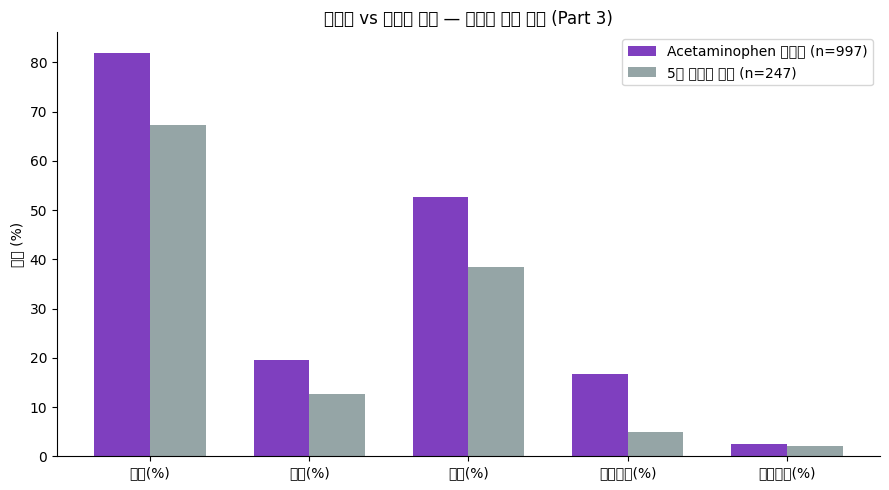

In [23]:
metrics = ['심각(%)', '사망(%)', '입원(%)', '생명위협(%)', '후유장애(%)']
x = np.arange(len(metrics))
width = 0.35
n_groups = len(groups3)

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(groups3.keys()):
    offset = (i - (n_groups - 1) / 2) * width
    vals = summary_df3.loc[name, metrics].values
    ax.bar(x + offset, vals, width, label=f'{name} (n={len(groups3[name])})', color=colors3[name])

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('비율 (%)')
ax.set_title('단일제 vs 복합제 전체 — 중증도 지표 비교 (Part 3)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**관찰**: 다른 성분이 전혀 섞이지 않은 아세트아미노펜 단일제가 오히려 복합제 전체보다 다섯 지표 모두에서 더 위중합니다 — 심각 82.0% vs 67.2%, 사망 19.5% vs 12.6%, 입원 52.7% vs 38.5%, 생명위협 16.8% vs 4.9%, 후유장애 2.4% vs 2.0%. 반면 문서화된 회복 비율은 단일제가 36.5%로 복합제 전체(24.3%)보다 오히려 더 높습니다 — 중증도는 더 높은데 회복률도 더 높은 이 역설적인 조합은, 아래 상위 이상반응(14장)과 대시보드(15.1절 기전)에서 그 이유가 드러납니다.

## 13. 연령대 · 성별 분포 (Part 3)

/tmp/ipykernel_1733/2881898131.py:18: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2881898131.py:18: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2881898131.py:18: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2881898131.py:18: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2881898131.py:18: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2881898131.py:18: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/2881898131.py:18: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_lay

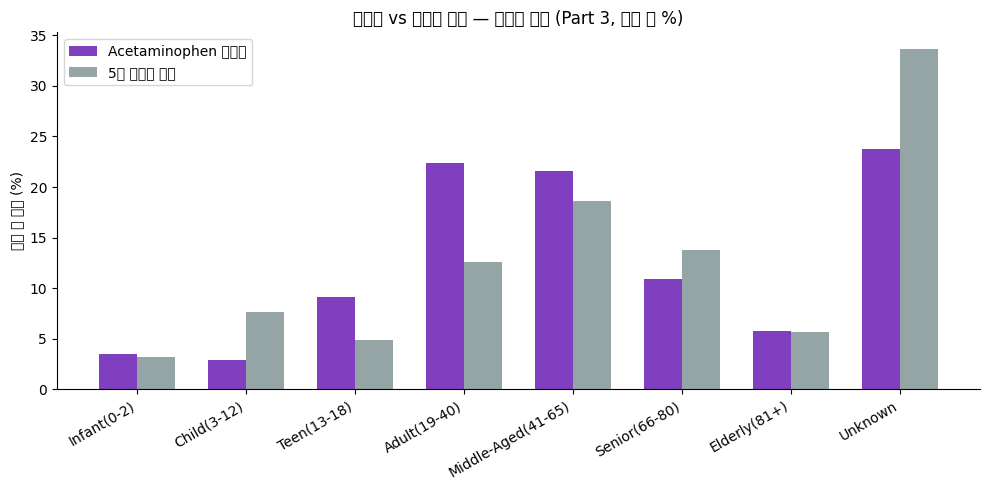

In [24]:
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']

fig, ax = plt.subplots(figsize=(10, 5))
xw = np.arange(len(age_order))
for i, (name, sub) in enumerate(groups3.items()):
    offset = (i - (len(groups3) - 1) / 2) * width
    counts = sub['age_group'].value_counts()
    pct = [counts.get(a, 0) / len(sub) * 100 for a in age_order]
    ax.bar(xw + offset, pct, width, label=name, color=colors3[name])

ax.set_xticks(xw)
ax.set_xticklabels(age_order, rotation=30, ha='right')
ax.set_ylabel('그룹 내 비율 (%)')
ax.set_title('단일제 vs 복합제 전체 — 연령대 분포 (Part 3, 그룹 내 %)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1733/3498106934.py:18: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3498106934.py:18: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3498106934.py:18: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3498106934.py:18: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3498106934.py:18: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3498106934.py:18: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3498106934.py:18: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  plt.tight

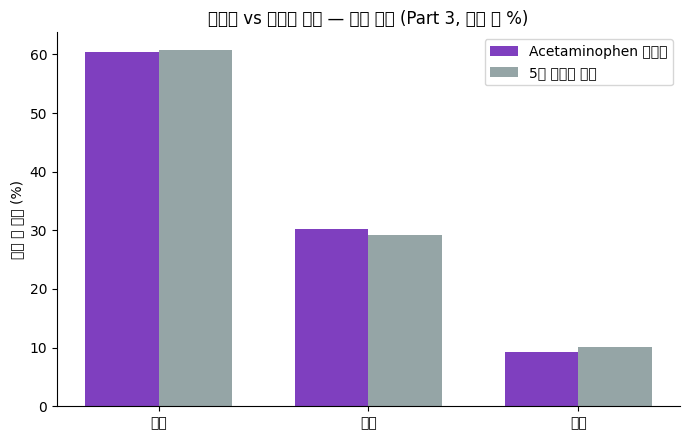

In [25]:
sex_order = ['Female', 'Male', 'Unknown']
sex_labels_ko = {'Female': '여성', 'Male': '남성', 'Unknown': '미상'}

fig, ax = plt.subplots(figsize=(7, 4.5))
xs = np.arange(len(sex_order))
for i, (name, sub) in enumerate(groups3.items()):
    offset = (i - (len(groups3) - 1) / 2) * width
    counts = sub['patient_sex'].value_counts()
    pct = [counts.get(s, 0) / len(sub) * 100 for s in sex_order]
    ax.bar(xs + offset, pct, width, label=name, color=colors3[name])

ax.set_xticks(xs)
ax.set_xticklabels([sex_labels_ko[s] for s in sex_order])
ax.set_ylabel('그룹 내 비율 (%)')
ax.set_title('단일제 vs 복합제 전체 — 성별 분포 (Part 3, 그룹 내 %)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**관찰**: 두 그룹의 평균연령(단일제 42.8세 vs 복합제 전체 45.3세)과 성별 분포(여성 60% 안팎으로 거의 동일)는 놀라울 정도로 비슷합니다. 차이는 연령대 '분포의 모양'에 있습니다 — 단일제는 Adult(19-40) 22.4%·Teen(13-18) 9.1%로 젊은 성인·청소년 비중이 복합제 전체(Adult 12.6%·Teen 4.9%)보다 뚜렷이 높습니다. 이는 14장에서 드러나는 의도적 과다복용/자해 관련 보고가 상대적으로 젊은 연령대에서 더 많이 나타나는 경향과 맞물립니다.

## 14. 상위 이상반응(Reaction) 비교 (Part 3)

/tmp/ipykernel_1733/3018054887.py:10: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3018054887.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3018054887.py:10: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3018054887.py:10: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3018054887.py:10: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3018054887.py:10: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/3018054887.py:10: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

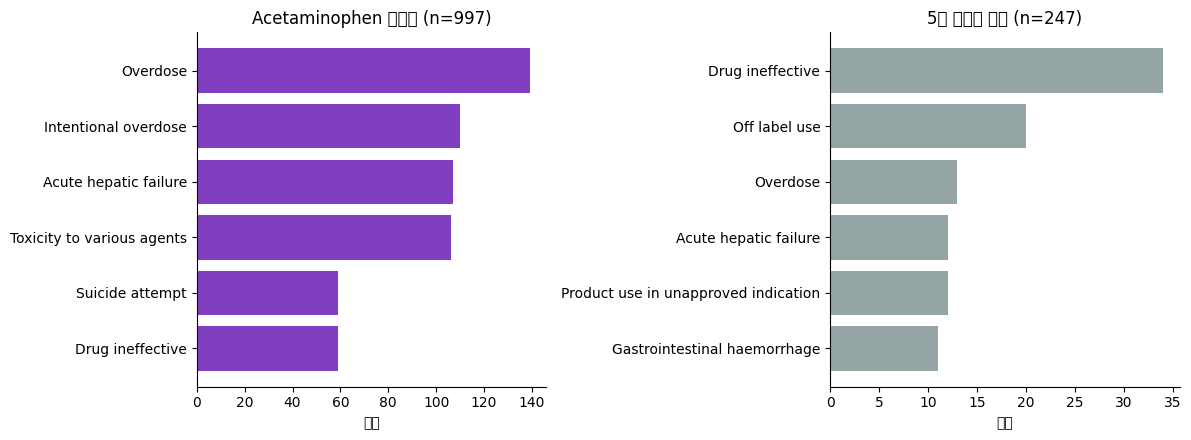

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, sub) in zip(axes, groups3.items()):
    rx = top_reactions(sub)
    labels = [r[0] for r in rx][::-1]
    vals = [r[1] for r in rx][::-1]
    ax.barh(labels, vals, color=colors3[name])
    ax.set_title(f'{name} (n={len(sub)})')
    ax.set_xlabel('건수')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**관찰**: 두 그룹의 이상반응 프로파일은 완전히 다른 이야기를 들려줍니다. 단일제 그룹은 Overdose(13.9%)·Intentional overdose(11.0%)·Suicide attempt(5.9%) 세 항목만 합쳐도 997건 중 308건(30.9%)에 달해, **의도적 자해/과다복용형 노출**이 핵심 축입니다. 여기에 Acute hepatic failure(10.7%)·Toxicity to various agents(10.6%)까지 더하면 상위 5개 항목 중 4개가 '중독·급성 장기손상' 계열입니다. 반면 복합제 전체 그룹은 Drug ineffective(13.8%)가 최다이고 Off label use·Product use in unapproved indication 등 **오사용·기대효과 미달** 계열이 상위를 차지하며, Overdose는 5.3%에 그칩니다. 즉 부성분이 없는 순수 아세트아미노펜은 '의도적 대량 섭취의 수단'으로, 부성분이 섞인 복합제는 '증상 완화용 자가치료 중 오사용'으로 보고되는 경향이 뚜렷이 갈립니다.

---

### 15.1 Acetaminophen 단일제 (n=997)

/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

병용약물 수: {'Polypharmacy(6+)': 336, 'Single': 267, '2-3 Drugs': 230, '4-5 Drugs': 143, 'Unknown': 21}
적응증 Top5: {'Product Used For Unknown Indication': 460, 'Pain': 93, 'Unknown': 45, 'Pyrexia': 39, 'Headache': 36}
연도별 건수: {'2015': 23, '2016': 34, '2017': 38, '2018': 22, '2019': 194, '2020': 21, '2021': 35, '2022': 112, '2023': 76, '2024': 80, '2025': 362}


/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1733/604518187.py:74: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

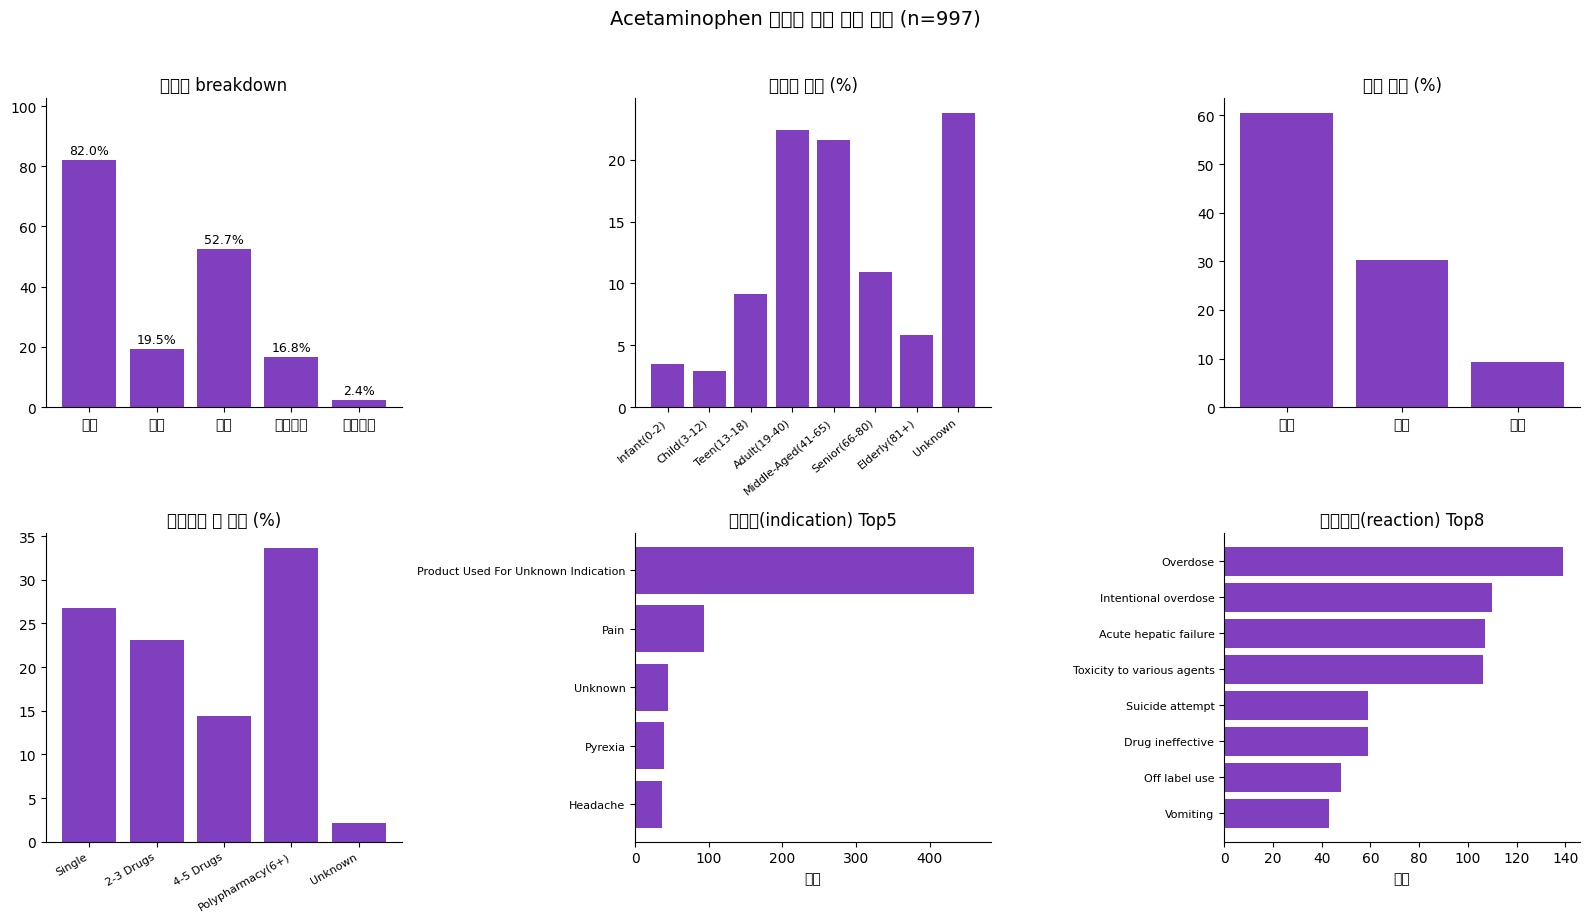

In [27]:
sub = groups3['Acetaminophen 단일제']
print('병용약물 수:', sub['drug_count_category'].value_counts().to_dict())
print('적응증 Top5:', sub['drug_indication'].value_counts().head(5).to_dict())
print('연도별 건수:', sub['quarter'].str[:4].value_counts().sort_index().to_dict())

plot_group_dashboard('Acetaminophen 단일제', sub, colors3['Acetaminophen 단일제'])

**대시보드 6개 그래프별 인사이트**

① **중증도 breakdown** — 심각 82.0%·입원 52.7%·사망 19.5%·생명위협 16.8%로 이 노트북에서 다룬 모든 그룹 중 가장 높습니다(후유장애만 2.4%로 상대적으로 낮음). Phenylephrine 그룹(심각 80.1%·사망 15.8%)을 근소하게 웃도는 수준입니다.

② **연령대 분포** — Unknown(23.8%)을 빼면 Adult(19-40) 22.4%·Middle-Aged(41-65) 21.6%가 최다이며, 평균연령 42.8세로 젊은 성인~중장년 중심입니다. Teen(13-18)도 9.1%로 다른 조합보다 높은 편입니다.

③ **성별 분포** — 여성 60.5%·남성 30.3%·Unknown 9.2%.

④ **병용약물 수 분포** — Polypharmacy(6+) 33.7%로 최다, Single(단독복용) 26.8%. 이 비중은 만성질환 병용이라기보다, ⑥에서 드러나듯 여러 약물을 한꺼번에 섭취한 다약제 과다복용 사례가 섞여 있을 가능성을 시사합니다.

⑤ **적응증 Top5** — Product Used For Unknown Indication(46.1%)이 압도적이며, Pain(9.3%)·Unknown(4.5%)·Pyrexia(3.9%)·Headache(3.6%)가 뒤를 잇습니다.

⑥ **이상반응 Top8** — Overdose(13.9%)·Intentional overdose(11.0%)·Acute hepatic failure(10.7%)·Toxicity to various agents(10.6%)·Suicide attempt(5.9%)가 상위 5개 중 4개를 차지해, 명백한 **의도적 대량섭취·자해 관련 급성 중독** 패턴을 보입니다.

**왜 이런 패턴이 나타날까? (기전)**
- *Overdose·Intentional overdose·Suicide attempt 30.9%(⑥)*: 아세트아미노펜은 처방 없이 대용량(500정 이상)으로도 구매 가능하고, 성분이 단 하나뿐이라 다른 부성분의 진정·오심 등 불쾌한 증상이 섭취량을 제한하지 않습니다. 아세트아미노펜은 전 세계적으로 처방전 없이 구매 가능한 약물 중 가장 흔한 자해성 과다복용 수단 중 하나로 알려져 있으며, 이번 데이터에서도 부성분이 전혀 섞이지 않았을 때 이 경향이 가장 뚜렷하게 나타납니다 — 6장에서 다룬 것처럼 복합제는 '치료적 중복 인지 실패'나 '자가선택 오남용'처럼 간접적인 경로로 과량에 이르는 반면, 단일제는 **의도적 대량 섭취라는 직접적인 경로**가 두드러집니다.
- *간부전·전신 중독 집중(①⑥)*: 6장에서 설명한 NAPQI 기전이 그대로 적용됩니다 — 간의 CYP2E1 효소가 아세트아미노펜 일부를 반응성 대사산물 NAPQI로 전환하고, 정상 용량에서는 글루타치온이 이를 즉시 해독하지만 하루 4g을 크게 초과하는 대량 섭취(특히 1회성 대량 섭취)에서는 글루타치온이 급격히 고갈되어 간세포가 광범위하게 괴사합니다. 부성분이 없어 '무엇을 함께 먹었는가'라는 교란 변수가 없다는 점에서, 이 그룹은 아세트아미노펜 자체의 간독성 기전이 가장 순수한 형태로 드러나는 사례라고 볼 수 있습니다.
- *중증도는 더 높은데 회복률도 더 높음(12장 요약표 참고)*: 단일제는 복합제 전체보다 중증도가 전반적으로 높은데도 문서화된 회복 비율은 36.5%로 복합제 전체(24.3%)보다 높습니다. 아세트아미노펜 과다복용은 **N-아세틸시스테인(NAC)이라는 확립된 해독제**가 있고, 혈중 농도 기반 표준 치료 프로토콜(Rumack-Matthew 노모그램 등)이 널리 쓰이고 있어 조기에 병원에 도착하면 급성 중증에도 불구하고 완전 회복으로 이어지는 경우가 많습니다. 반면 복합제 그룹은 대부분 경미한 오사용·효과 미달 사례라 애초에 적극적 치료·추적이 이뤄지지 않아 회복 여부가 명시적으로 기록되지 않는(Unknown으로 남는) 경우가 많은 것으로 추정됩니다.
- *다약제 병용 33.7%(④)*: 이 비율은 Diphenhydramine 조합(5.1절)처럼 만성질환약과의 치료적 중복이 아니라, 자해 목적으로 **여러 약물을 한꺼번에 섭취하는 혼합 과다복용(polydrug overdose)** 사례가 다수 섞여 있기 때문으로 추정됩니다 — ⑥의 Suicide attempt·Intentional overdose 비중과 정합적입니다.
- *젊은 성인·청소년 비중(②)*: Adult(19-40) 22.4%+Teen(13-18) 9.1%로 다른 그룹보다 젊은 연령대 비중이 높은 것은, 의도적 자해성 과다복용이 청년층에서 상대적으로 더 흔하게 보고되는 경향과 일치합니다.

---

## 16. 단일제가 복합제와 다른 이유 — 도메인 지식 (Part 3)

단일제와 복합제 전체는 사실 **같은 분자(아세트아미노펜)의 같은 간독성 기전**을 공유합니다(6장 참고: CYP2E1 → NAPQI → 글루타치온 고갈 → 간세포 괴사). 차이는 **"얼마나 많은 양이, 어떤 경로로 하루 4g 한계를 넘기는가"**에 있습니다.

| 그룹 | 과량에 이르는 주된 경로 | 상위 이상반응 성격 | 중증도 |
|---|---|---|---|
| 단일제(Monotherapy) | 다른 부성분의 제한(진정·오심 등) 없이, **의도적 대량 섭취**(자해) 또는 아세트아미노펜 자체의 반복 중복복용으로 직접 과량에 도달 | Overdose·Intentional overdose·Suicide attempt·Acute hepatic failure — **중독형** | 가장 높음(심각 82.0%·사망 19.5%·생명위협 16.8%) |
| 복합제 전체 | 부성분(항히스타민의 진정효과 오인, 페닐에프린의 낮은 생체이용률, 소아 액상제형의 계량오류 등)이 만드는 **간접적 사용/오용 경로**를 통해 과량 또는 오사용에 도달 | Drug ineffective·Off label use·Incorrect dose administered — **오사용/기대효과 미달형** | 상대적으로 낮음(심각 67.2%·사망 12.6%·생명위협 4.9%) |

**왜 순수 단일제가 자해 수단으로 더 자주 보고되는가**: 복합제는 대부분 부성분 자체가 '섭취량을 제한하는 안전장치' 역할을 부수적으로 합니다 — 디펜히드라민(항콜린 오심·심한 졸림), 아스피린(위장관 자극), 카페인(과다 시 심계항진·불안)처럼 다량 섭취 시 불쾌한 증상이 빠르게 나타나 추가 섭취를 저지하거나, 소아용 제형은 병당 총 함량이 적어 물리적으로 대량 섭취 자체가 어렵습니다. 반면 순수 아세트아미노펜(특히 Extra Strength 500mg 정제, 대용량 병)은 급성 불쾌 증상 없이(초기 무증상 잠복기) 치명적 용량까지 섭취가 가능해, 처방전 없이 구매 가능한 진통제 중 자해 수단으로 가장 흔히 보고되는 약물 중 하나로 알려져 있습니다. 이 노트북의 데이터에서도 이런 특성이 그대로 반영되어, 부성분이 전혀 섞이지 않은 단일제 그룹에서 의도적 과다복용·자해 관련 이상반응 비중이 가장 높게 나타난 것으로 해석됩니다.

**참고(해석의 한계)**: 위 해석은 이 FAERS 서브셋(51개 브랜드, 1,248건)에 대한 기술적(descriptive) 관찰이며, 인과관계를 확정하는 통계적 검정을 수행한 것은 아닙니다. '단일제'와 '5개 복합제 전체' 두 그룹은 정의상 서로 완전히 배타적이지만, 두 그룹의 합(997+247=1,244건)이 전체 건수(1,248건)와 정확히 일치하지는 않습니다 — 이 노트북에서 다루지 않은 다른 복합제 조합(예: 이번에 추적하지 않은 성분 조합)에 해당하는 소수의 행이 어느 그룹에도 속하지 않기 때문입니다.